Dataset shape: (2148, 99)

Columns:
 ['URL', 'Price', 'Intérieurs - Chargeur CD', 'Intérieurs - Autoradio CD', 'Sécurité - Airbags rideaux', 'Fonctionnels - Climatisation automatique', 'Spécifications - Nombre de portes', 'Intérieurs - Sièges massants', 'Intérieurs - Autoradio CD/Mp3', 'Intérieurs - 3 appuis têtes arrières', 'Extérieurs - Coffre électrique', 'Sécurité - ABS', 'Intérieurs - Sièges réglables en hauteur', 'Extérieurs - Radar de recul', 'Sécurité - Fixations ISOFIX', 'Carrosserie', 'Extérieurs - Toit panoramique', 'Motorisation - Énergie', 'Sécurité - Anti-démarrage électronique', 'Intérieurs - Sièges sport', 'Fonctionnels - Direction assistée', 'Fonctionnels - Vitres électriques', 'Sécurité - Radiateur tropicalisé', 'Extérieurs - Jantes en alliage', 'Spécifications - Modèle', 'Motorisation - Transmission', 'Énergie', "Date de l'annonce", 'Intérieurs - Accoudoir arrière', 'Extérieurs - Caméras 360', 'Fonctionnels - Allumage automatique des feux', 'Intérieurs - Connectivité

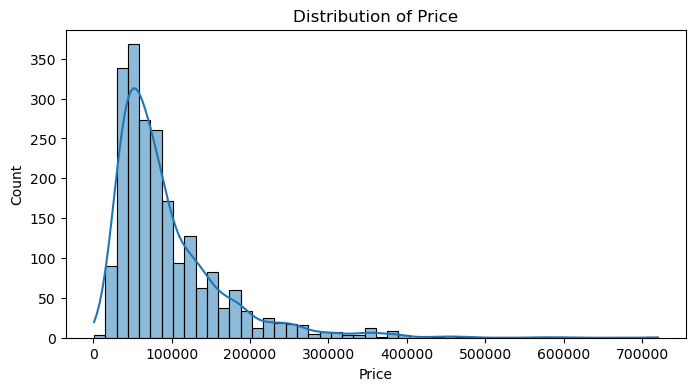

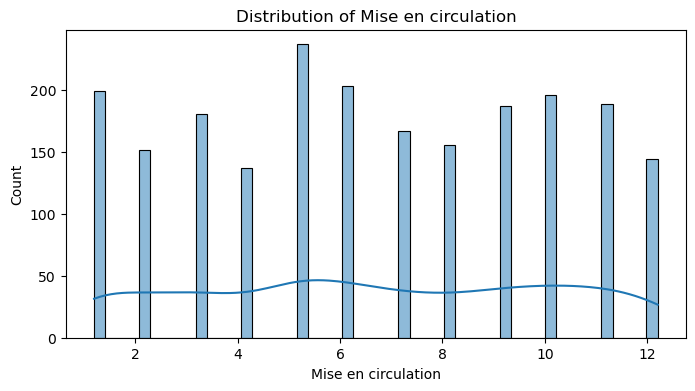

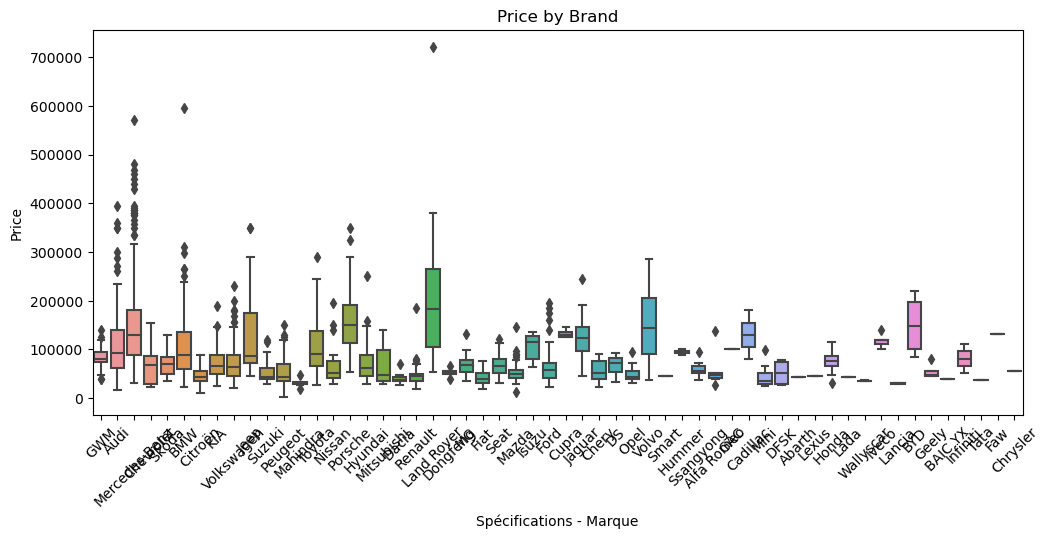

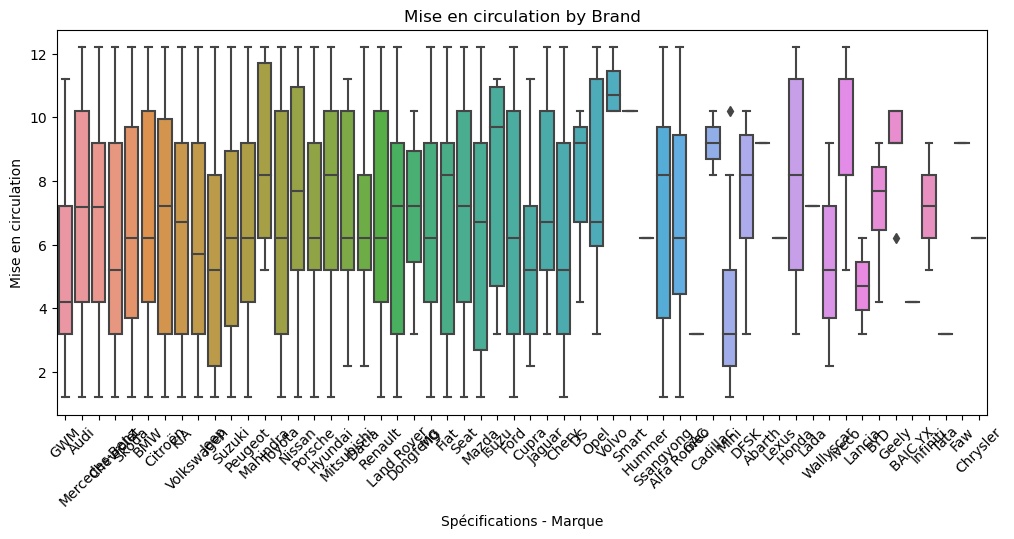


Categorical summary:

URL unique values: 2146
https://www.automobile.tn/fr/occasion/land-rover/range-rover-evoque/118222    2
https://www.automobile.tn/fr/occasion/seat/ibiza/118594                       2
https://www.automobile.tn/fr/occasion/great-wall/jolion/120671                1
https://www.automobile.tn/fr/occasion/hyundai/ix35/120522                     1
https://www.automobile.tn/fr/occasion/great-wall/jolion/116996                1
https://www.automobile.tn/fr/occasion/kia/rio-5p/119965                       1
https://www.automobile.tn/fr/occasion/renault/megane-sedan/107292             1
https://www.automobile.tn/fr/occasion/ford/ecosport/104655                    1
https://www.automobile.tn/fr/occasion/citroen/c-elysee/120520                 1
https://www.automobile.tn/fr/occasion/renault/kadjar/120523                   1
Name: URL, dtype: int64

Intérieurs - Chargeur CD unique values: 2
No     1904
Yes     244
Name: Intérieurs - Chargeur CD, dtype: int64

Intérieurs - Aut

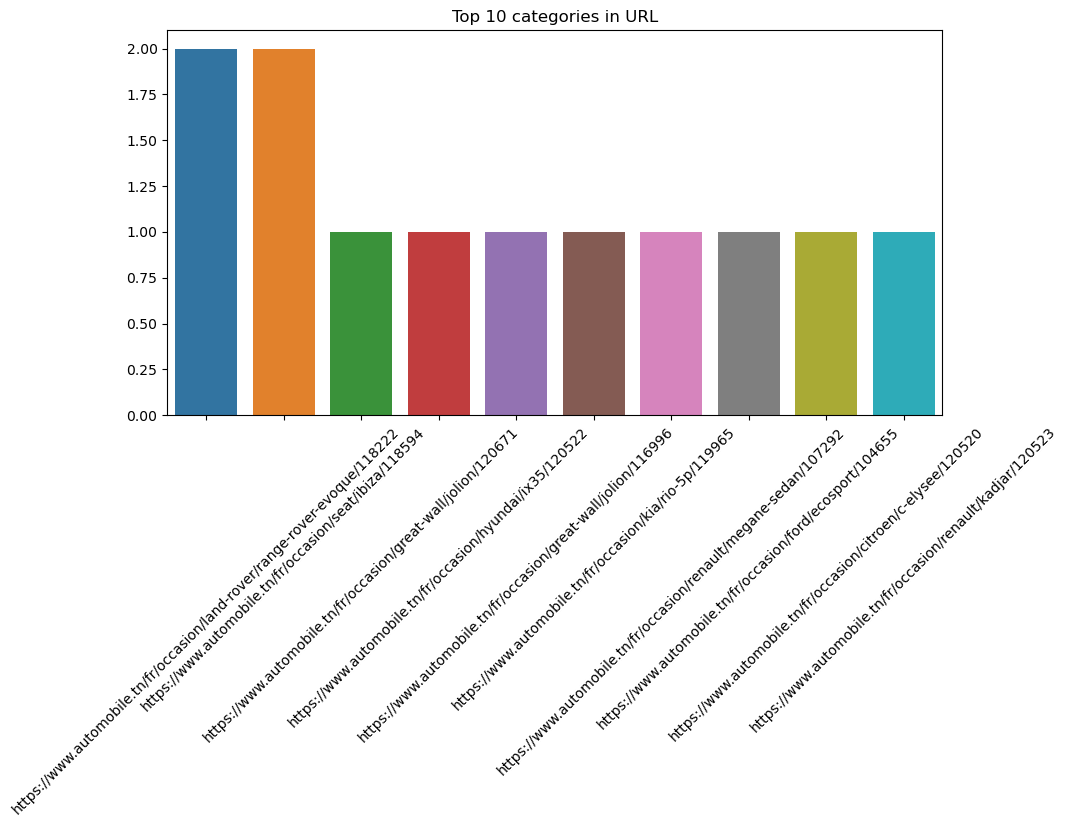

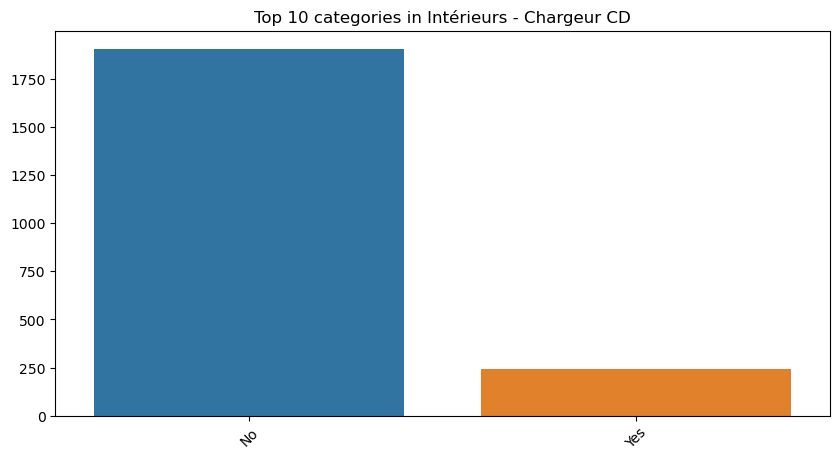

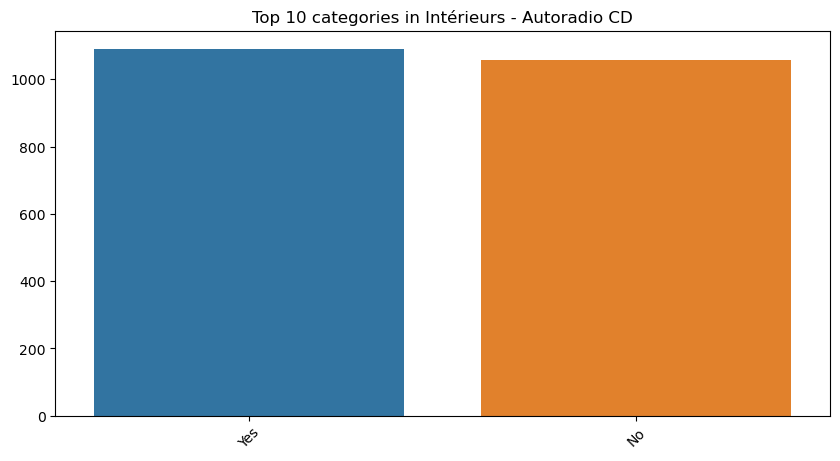

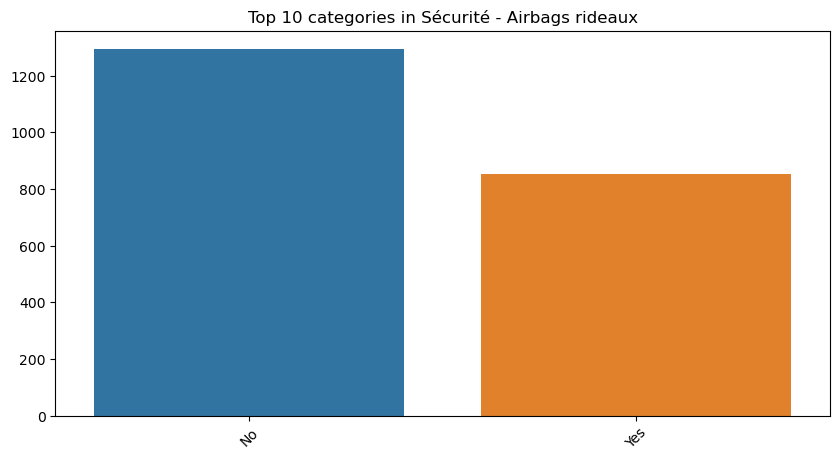

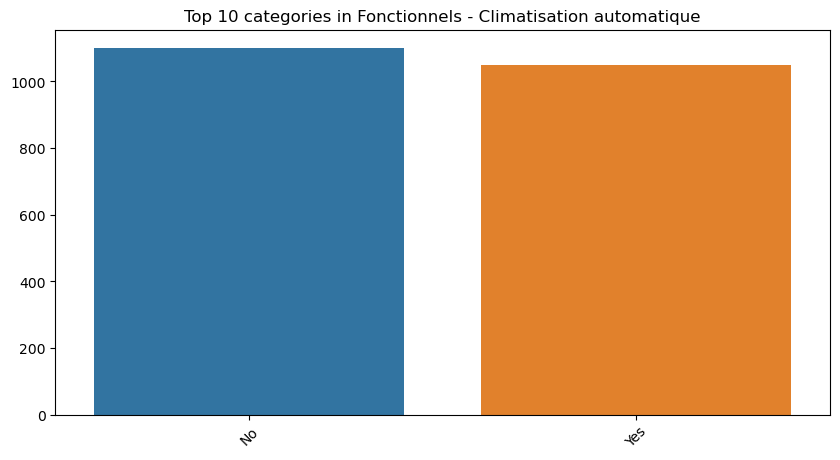

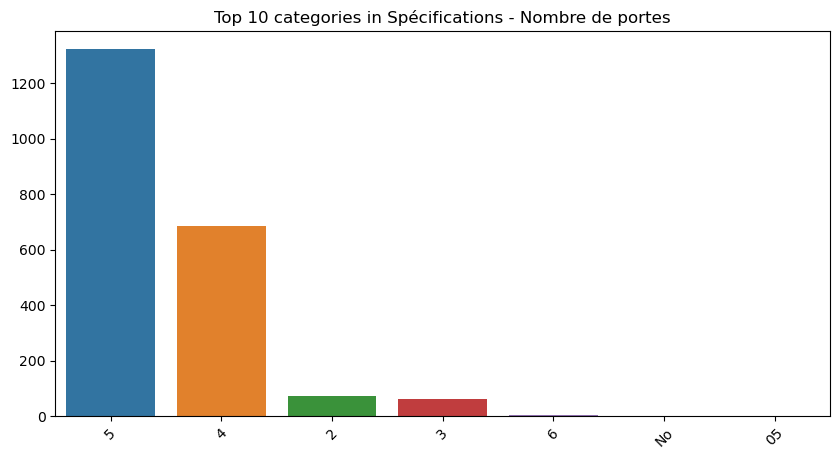

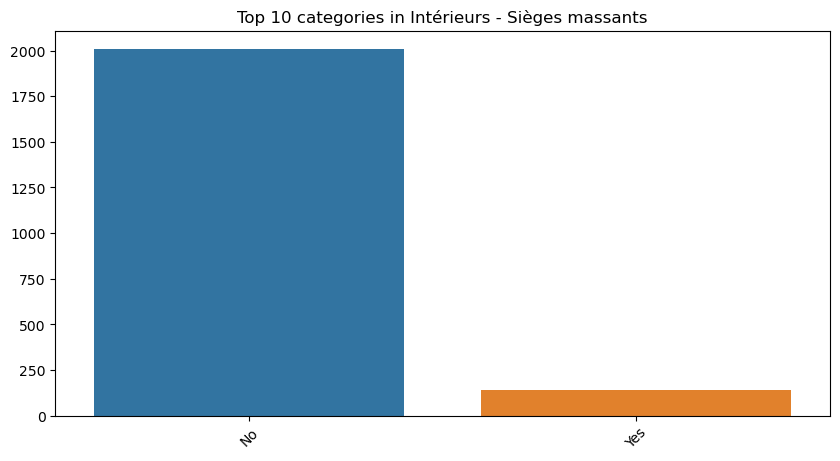

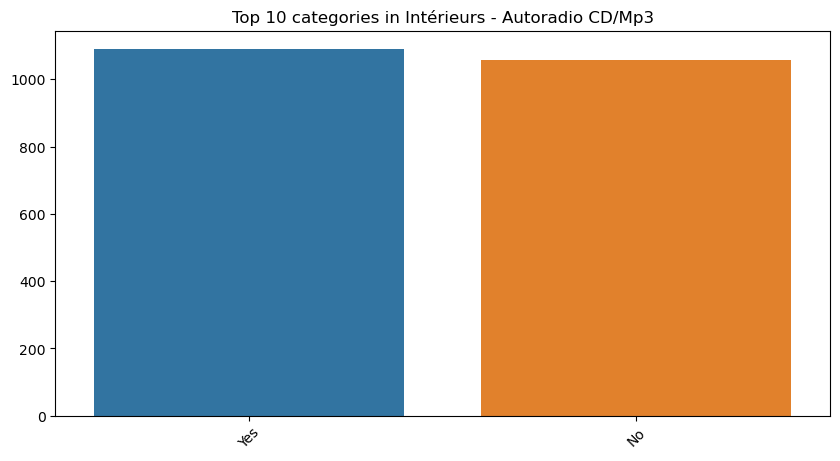

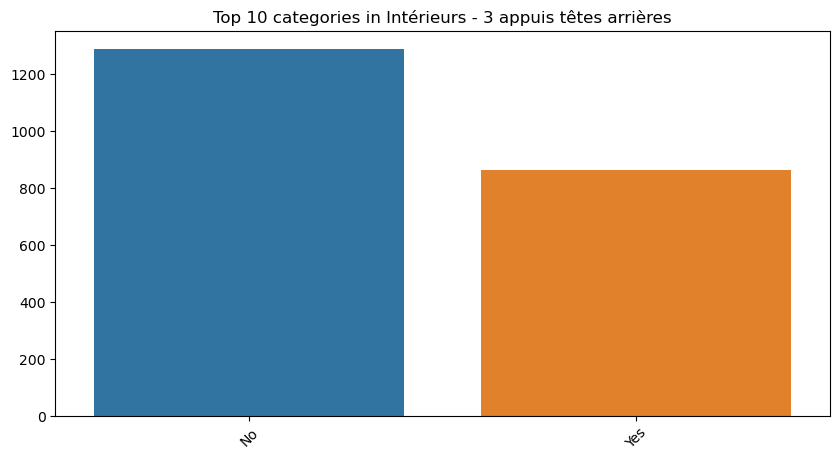

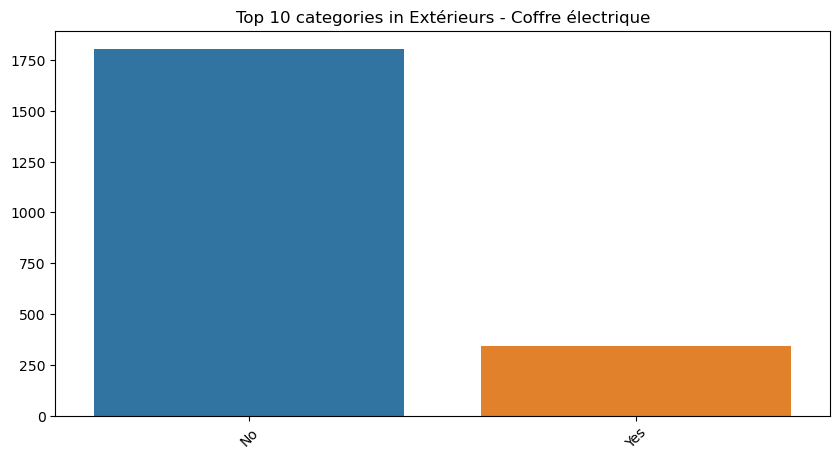

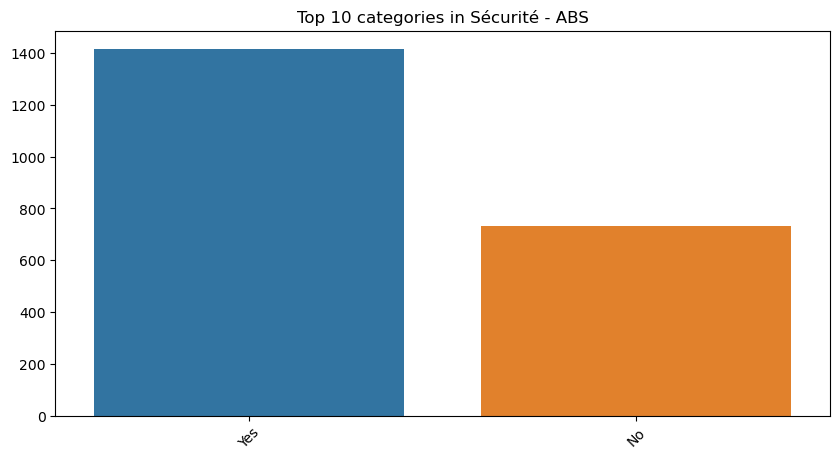

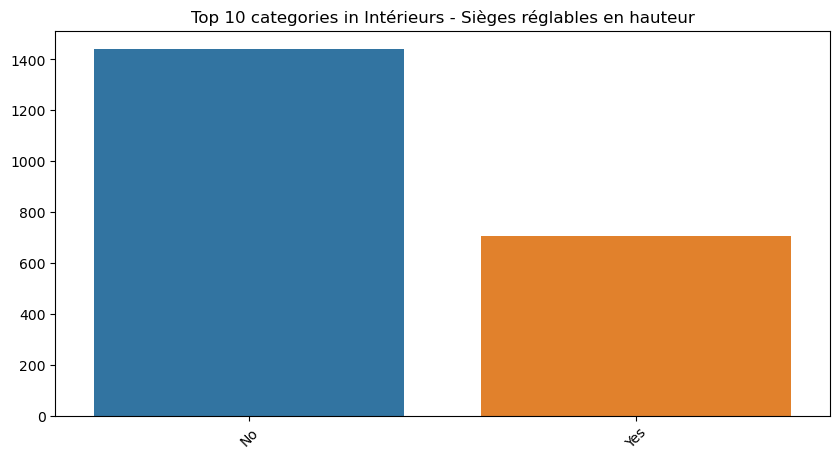

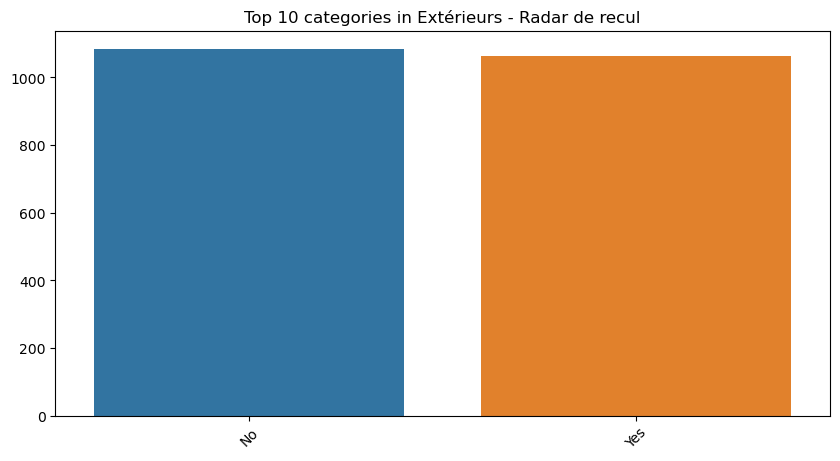

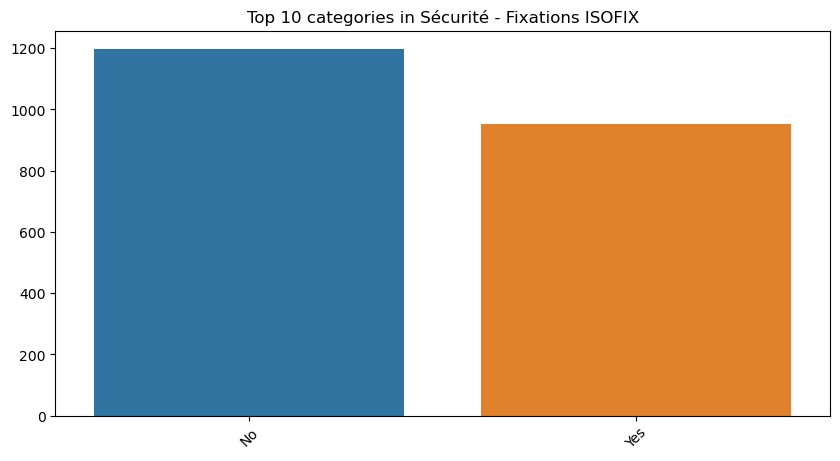

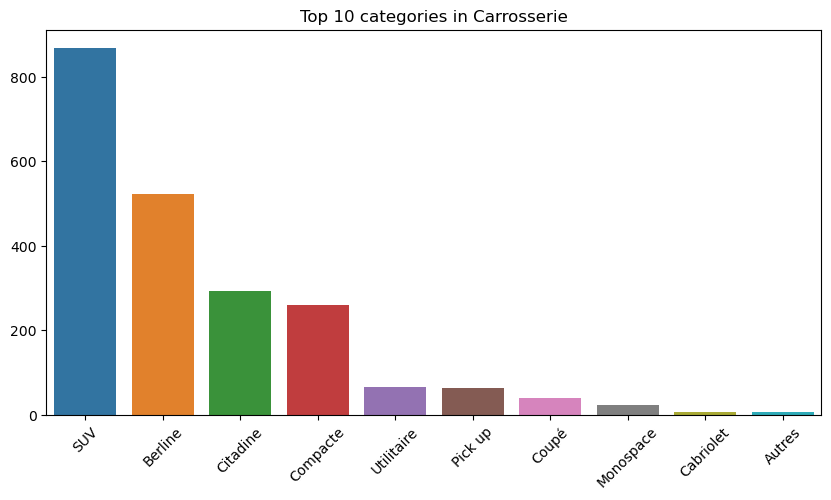

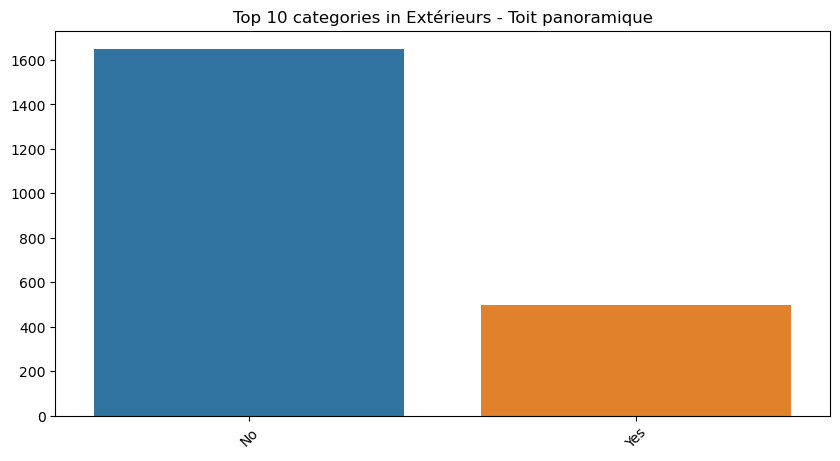

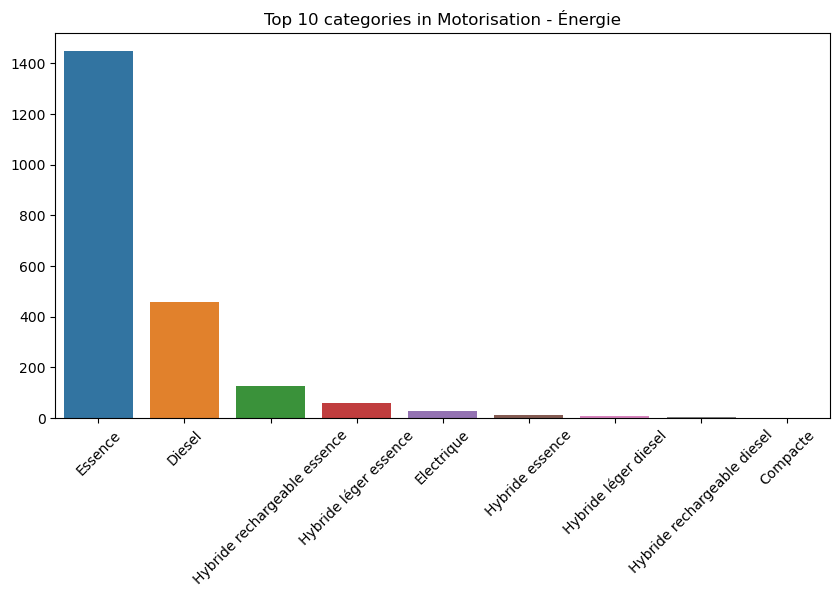

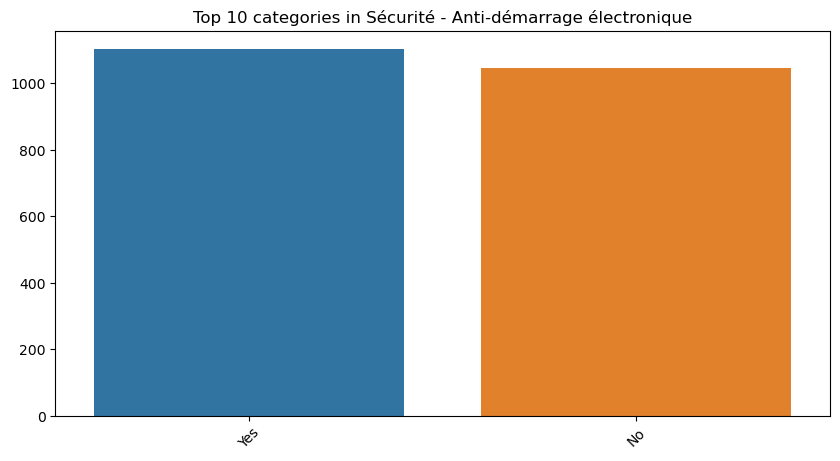

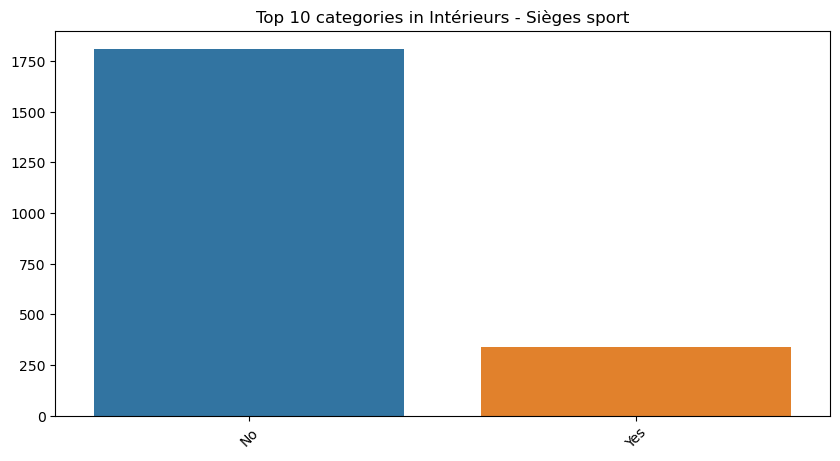

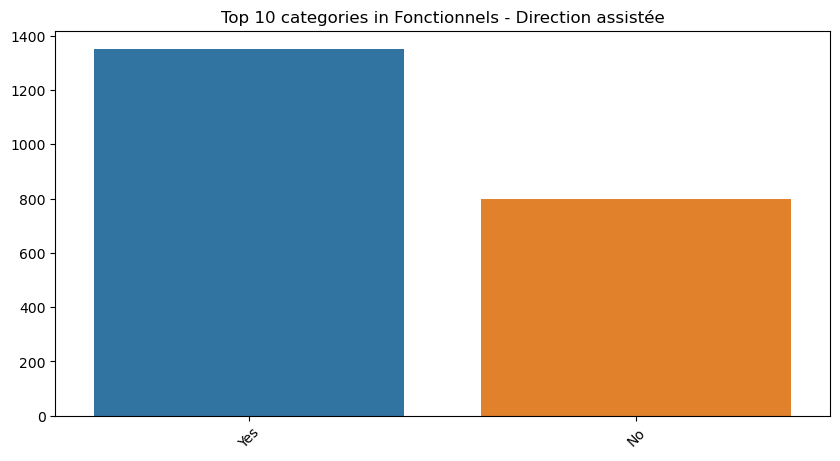

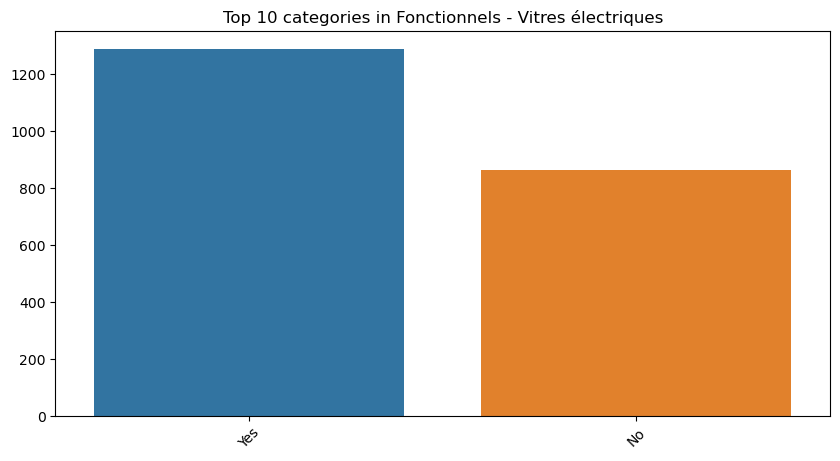

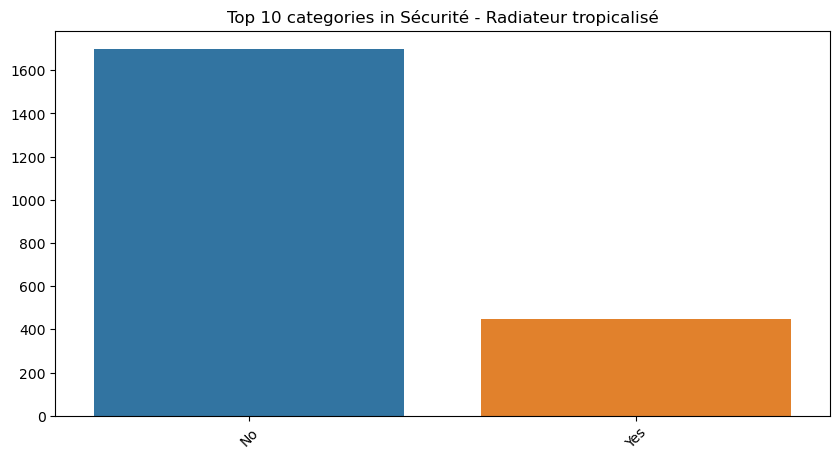

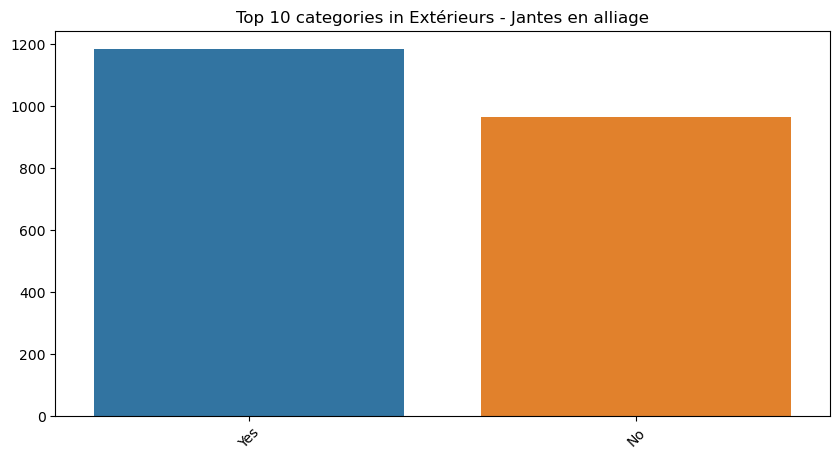

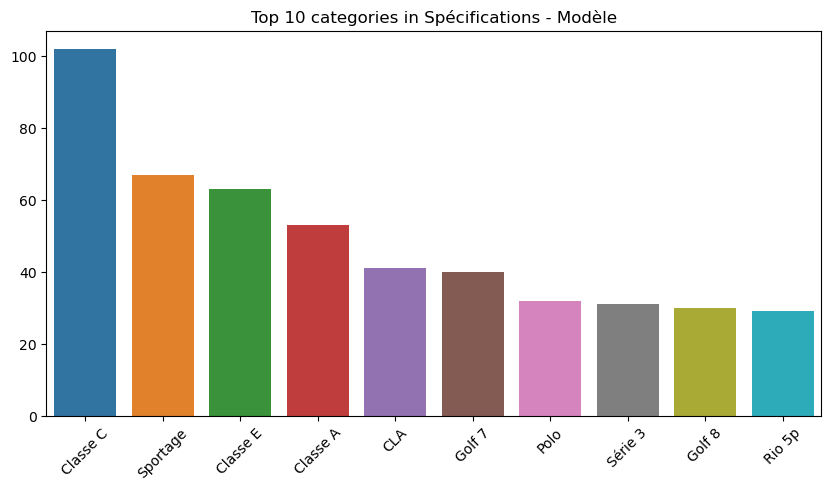

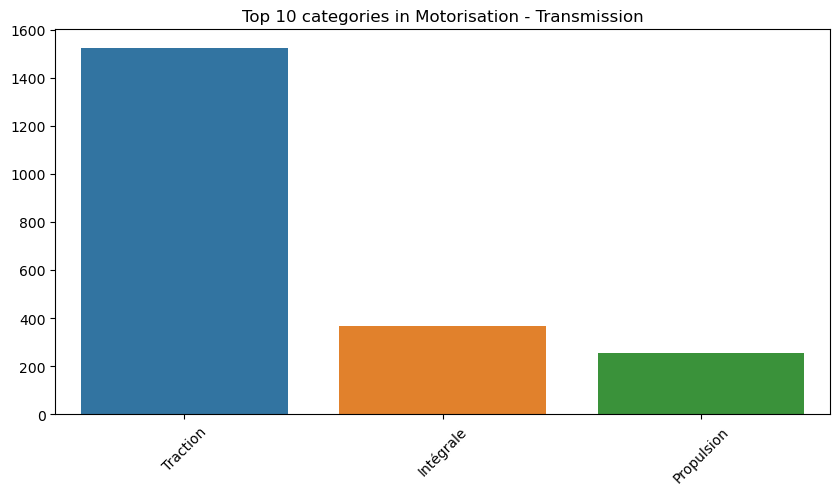

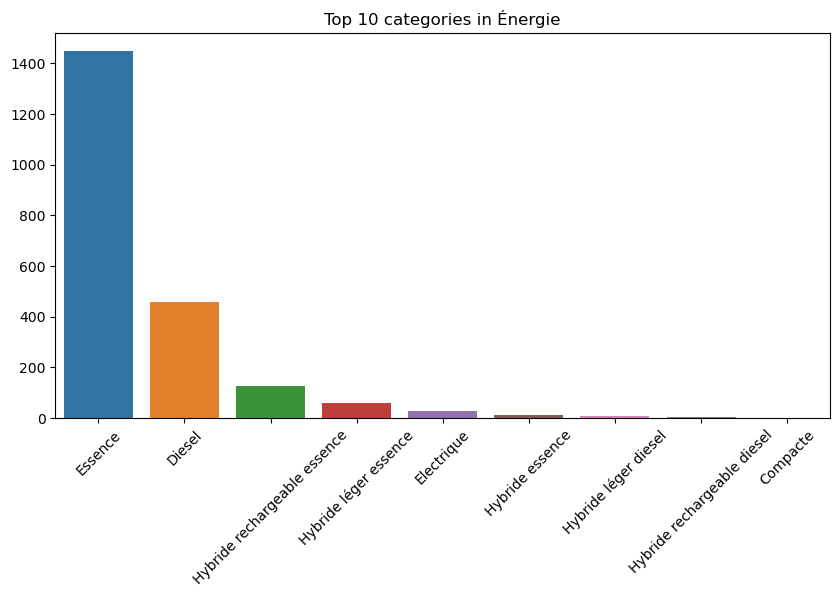

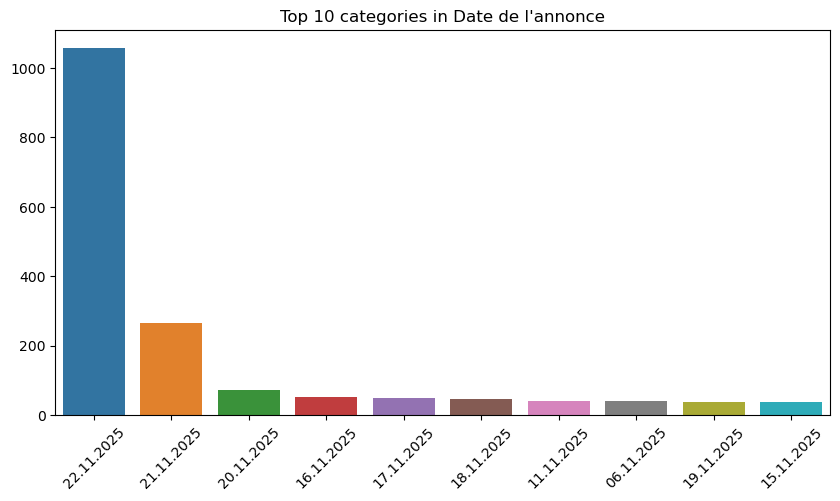

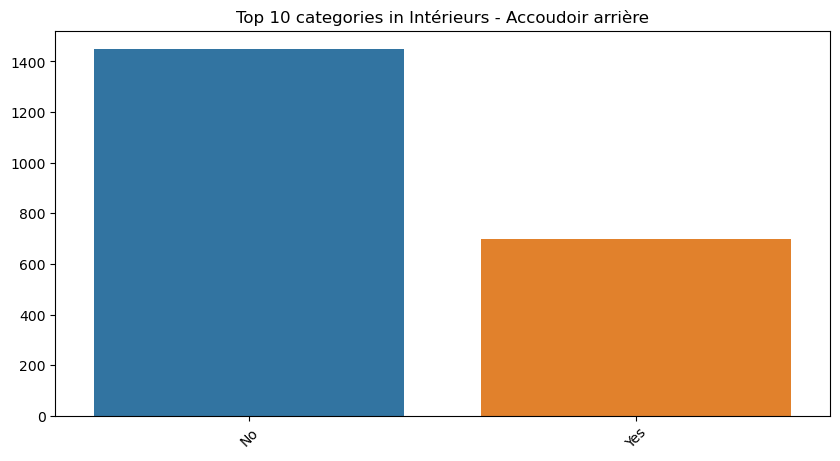

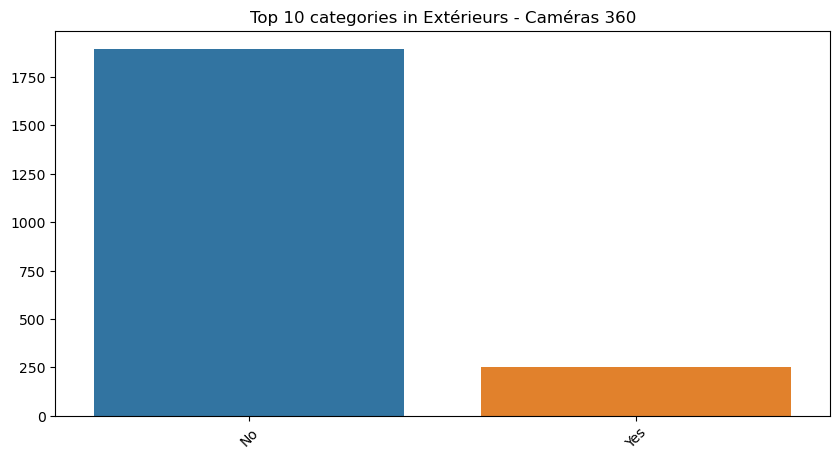

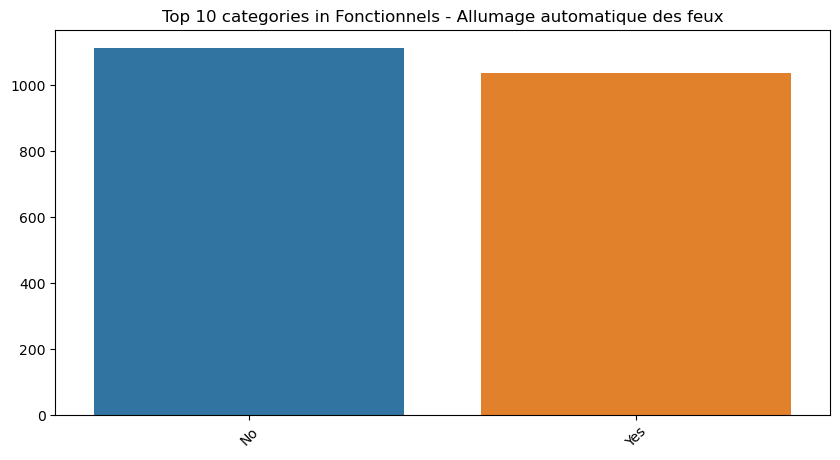

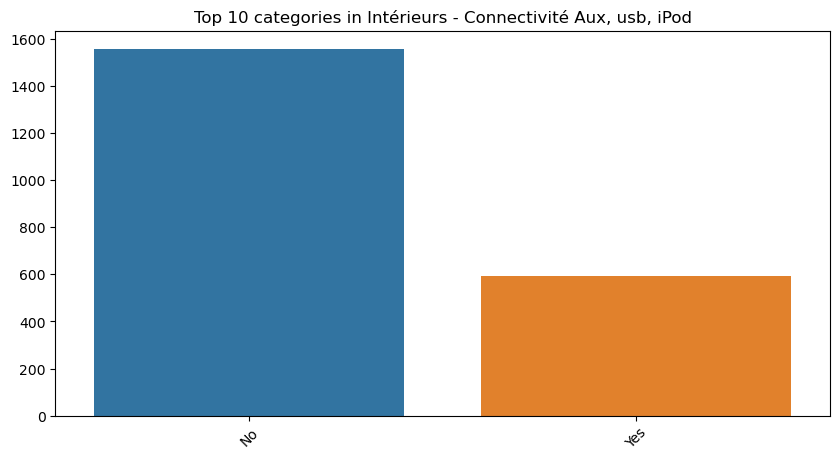

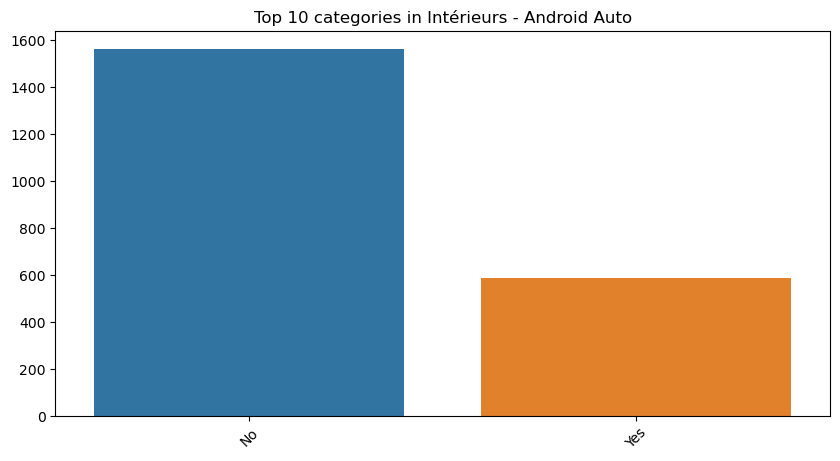

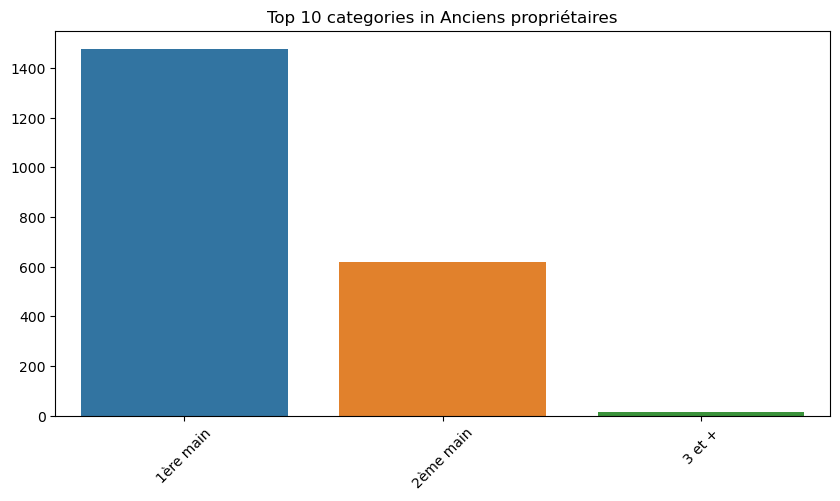

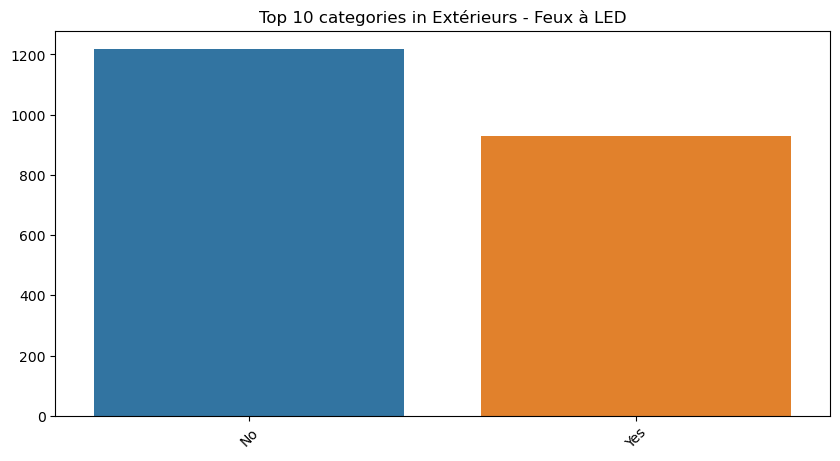

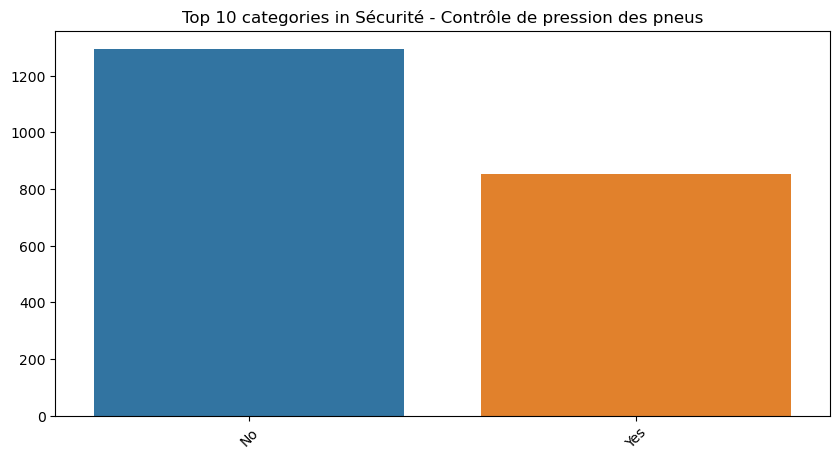

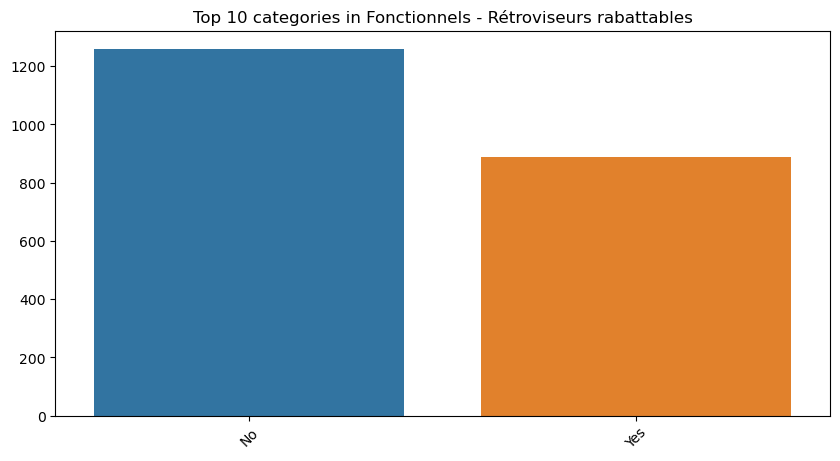

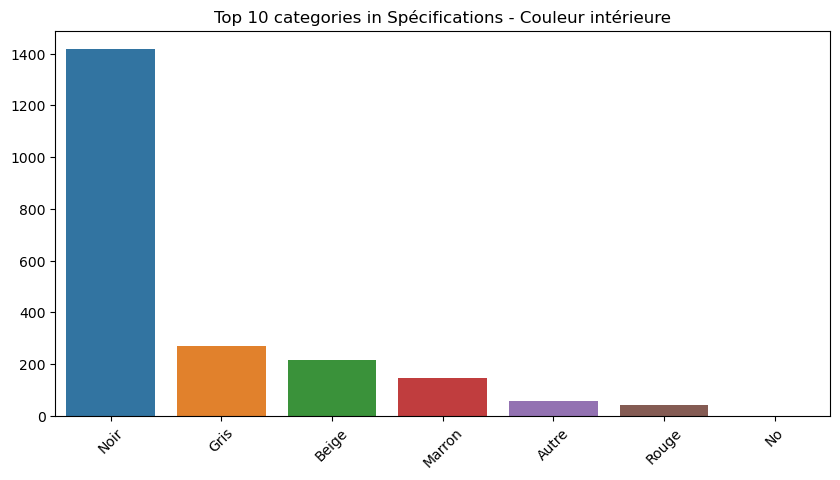

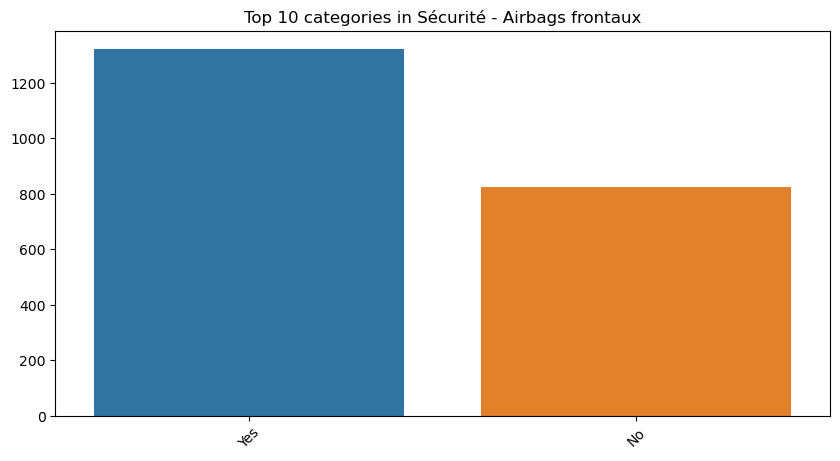

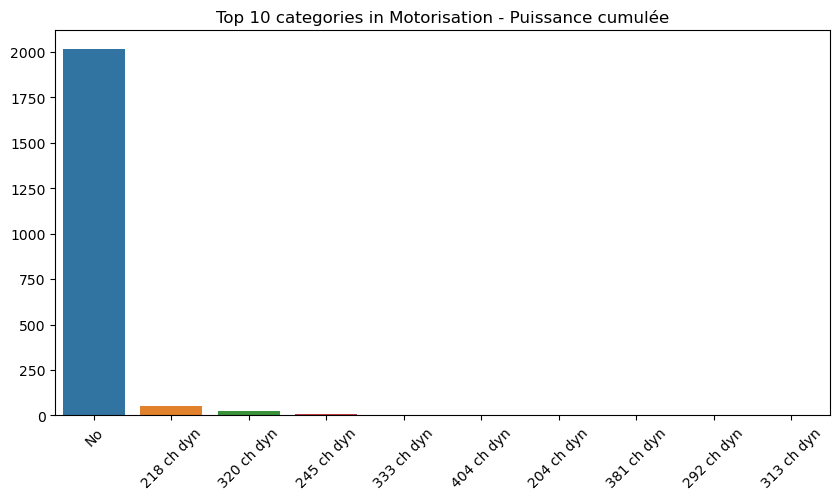

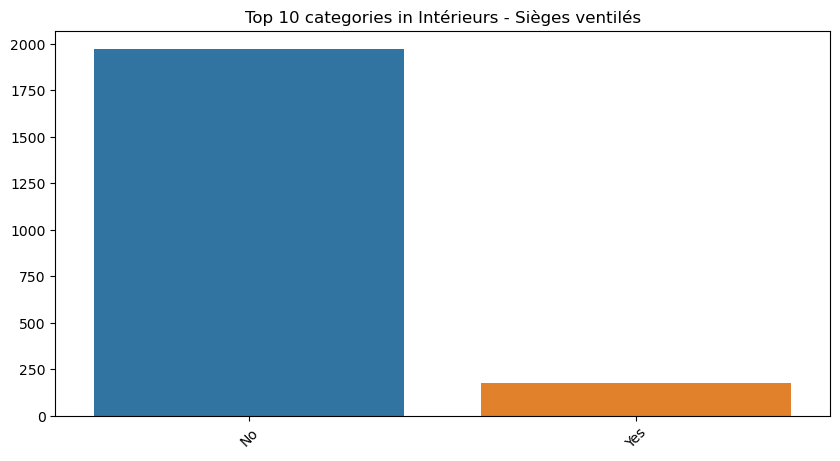

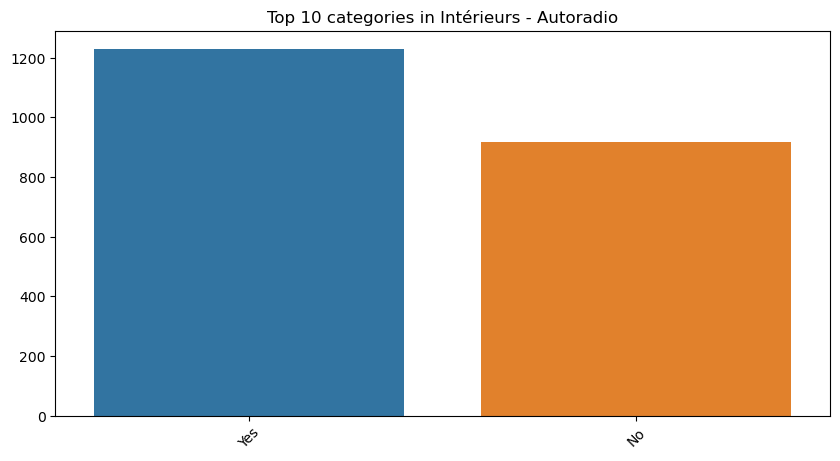

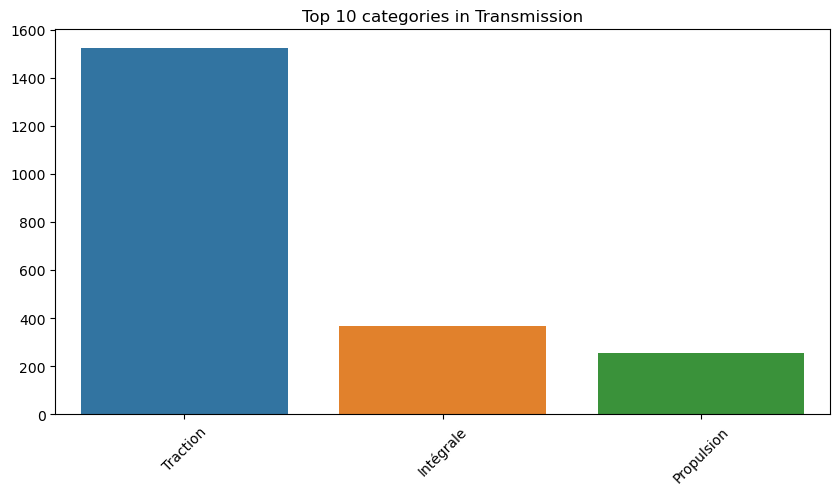

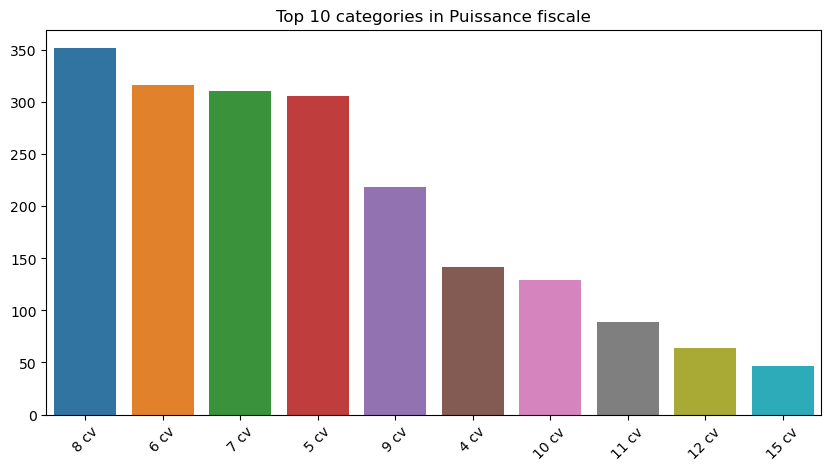

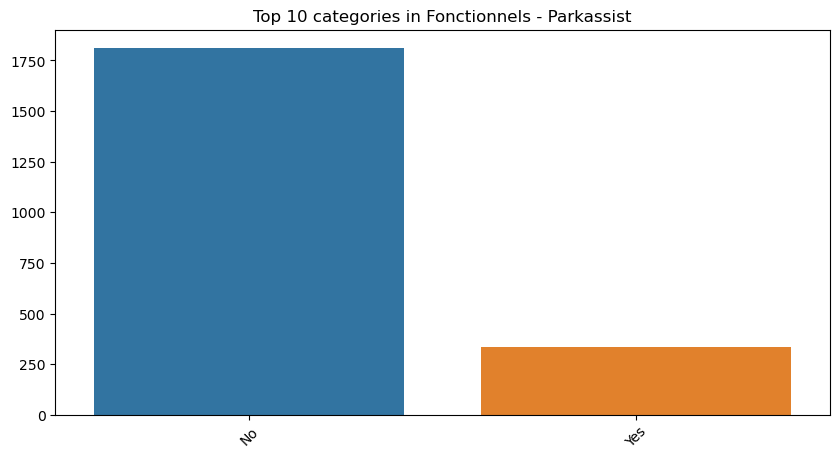

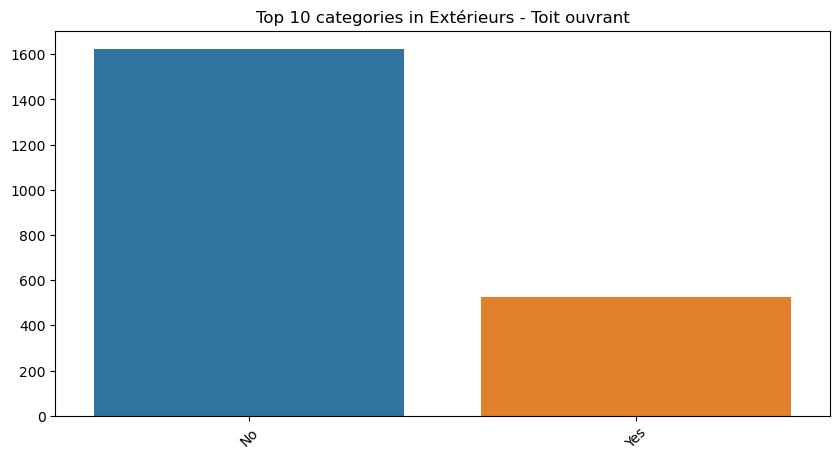

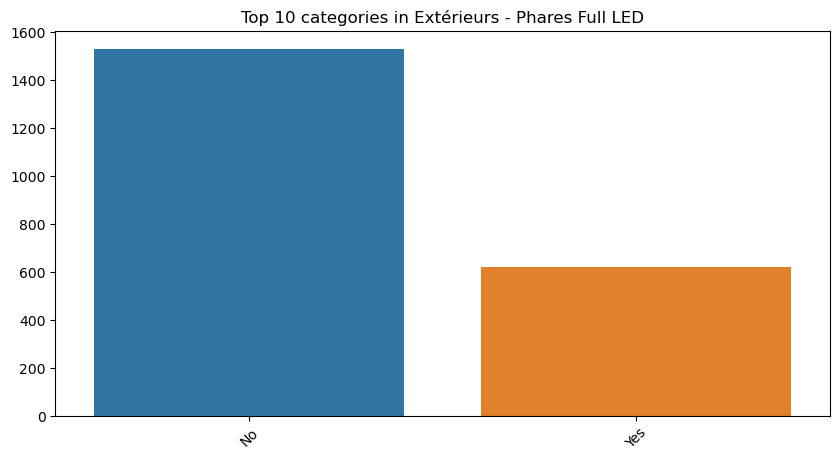

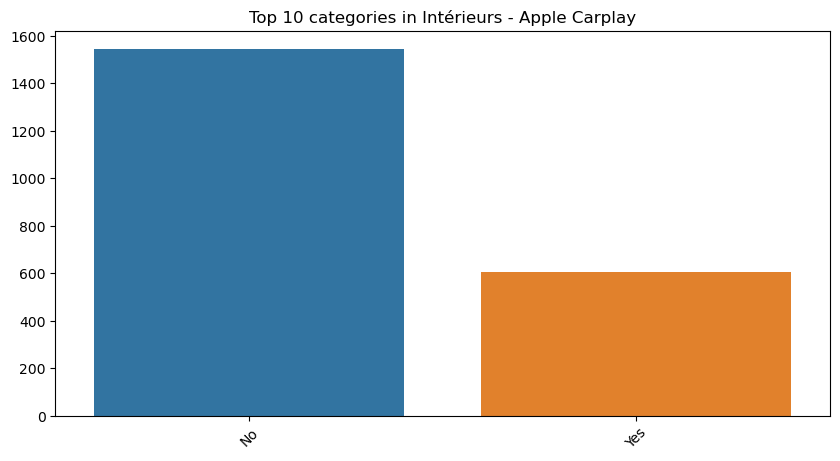

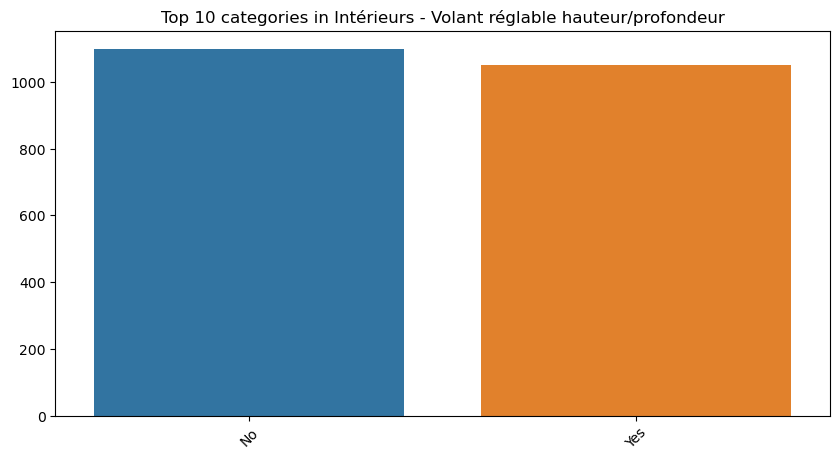

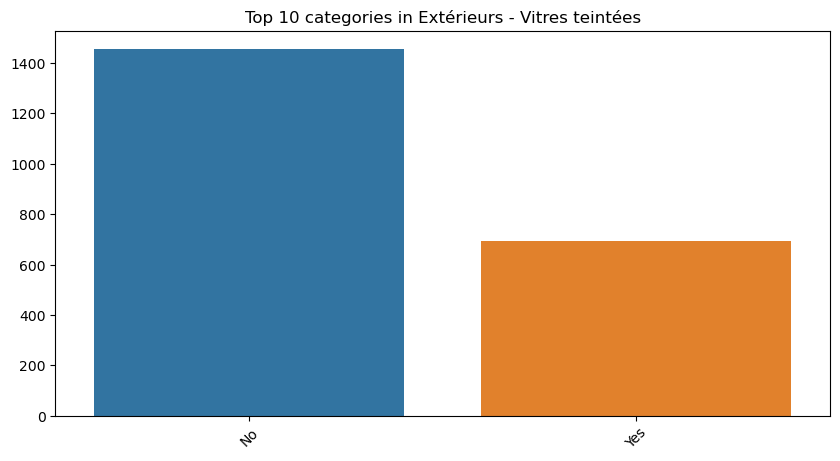

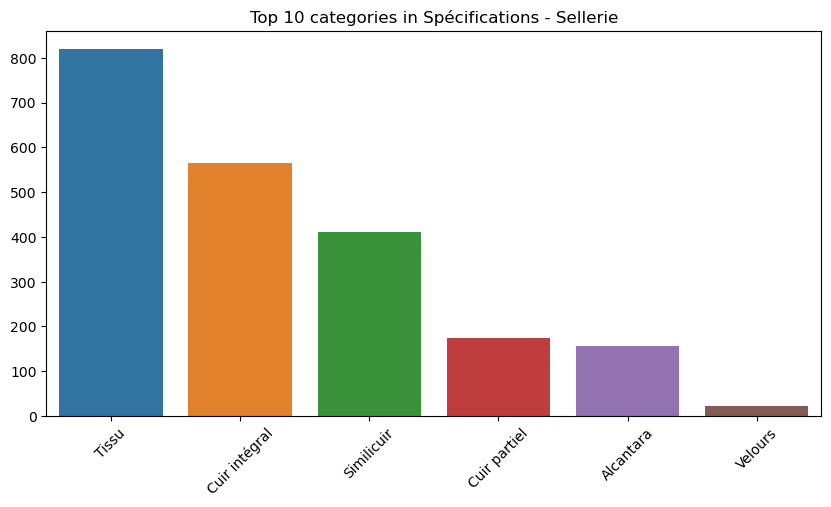

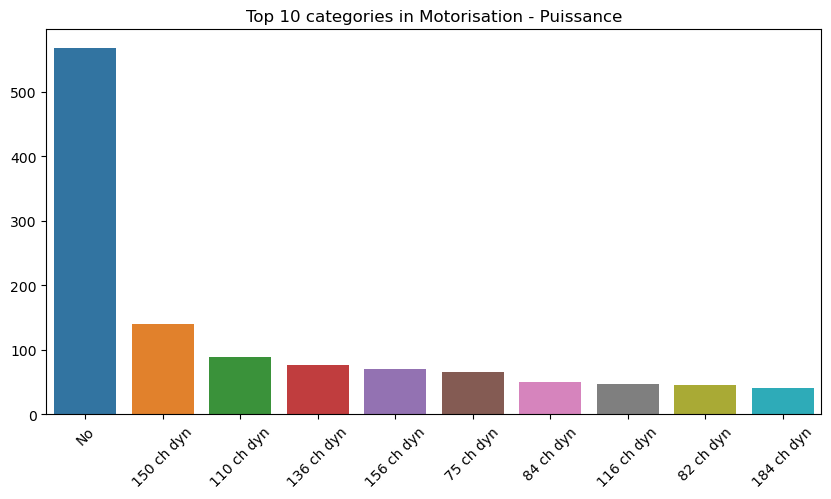

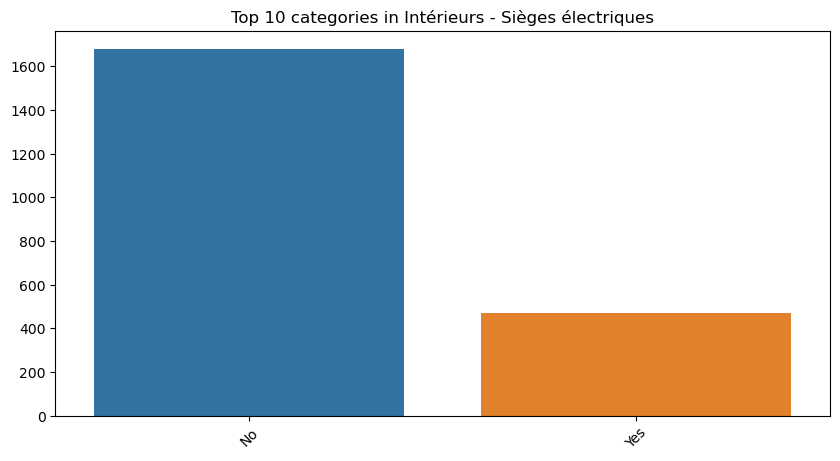

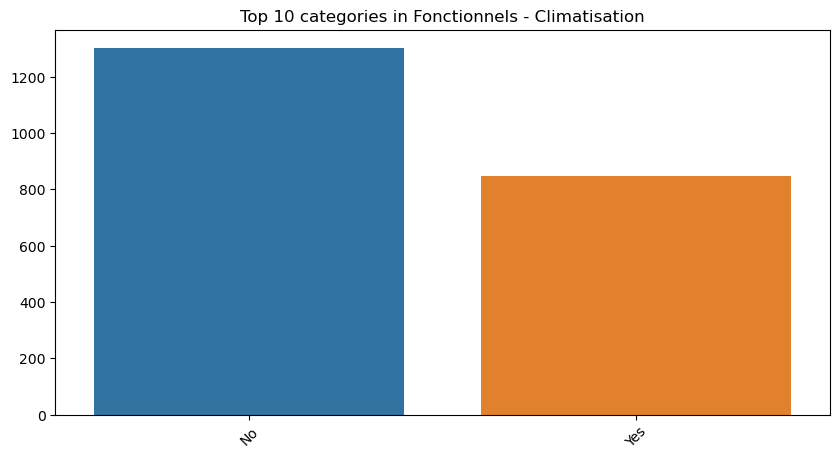

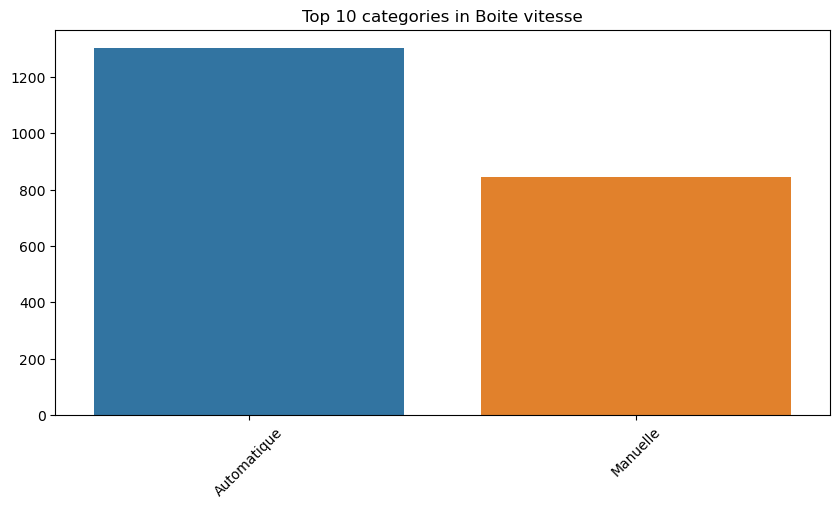

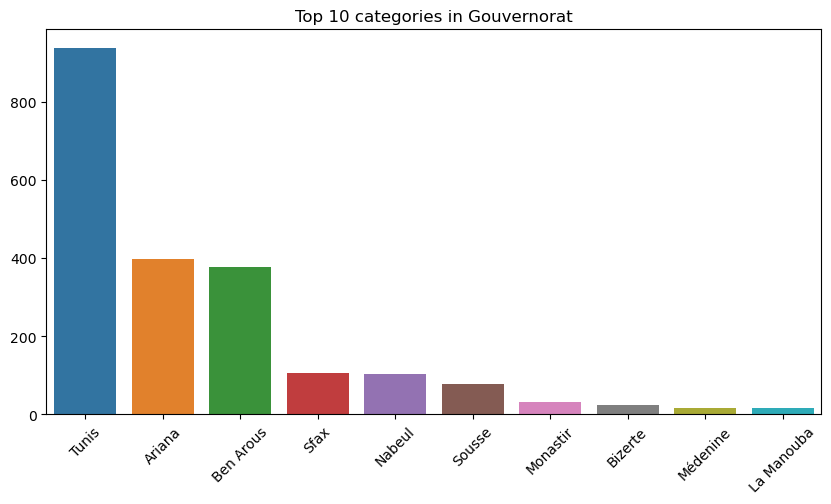

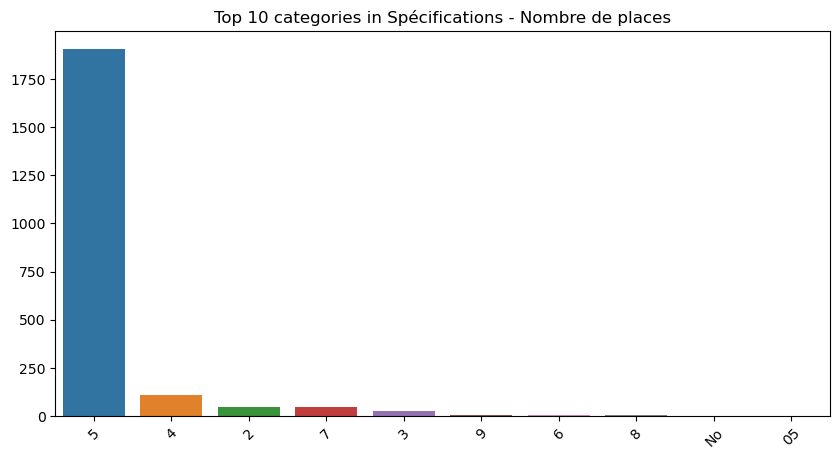

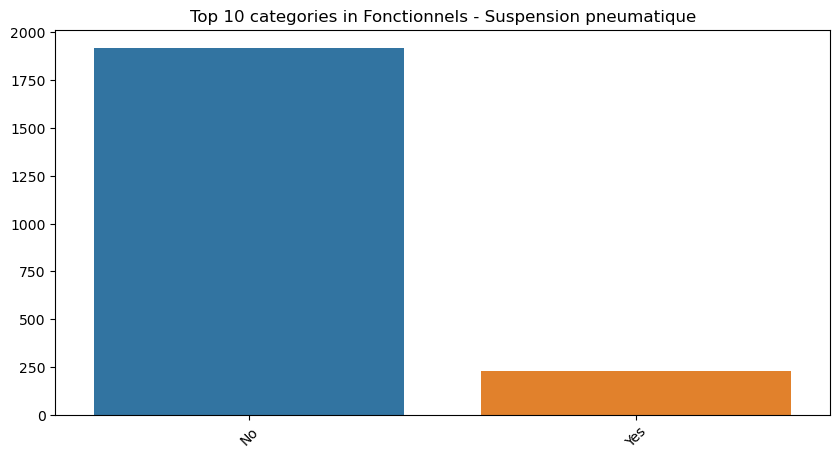

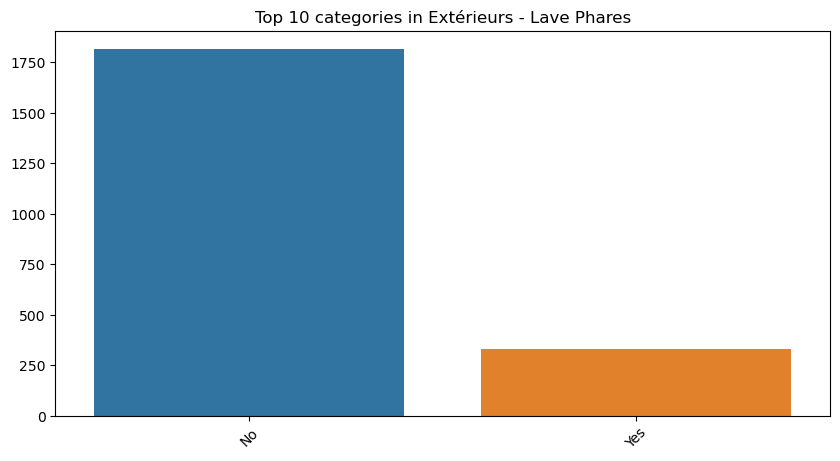

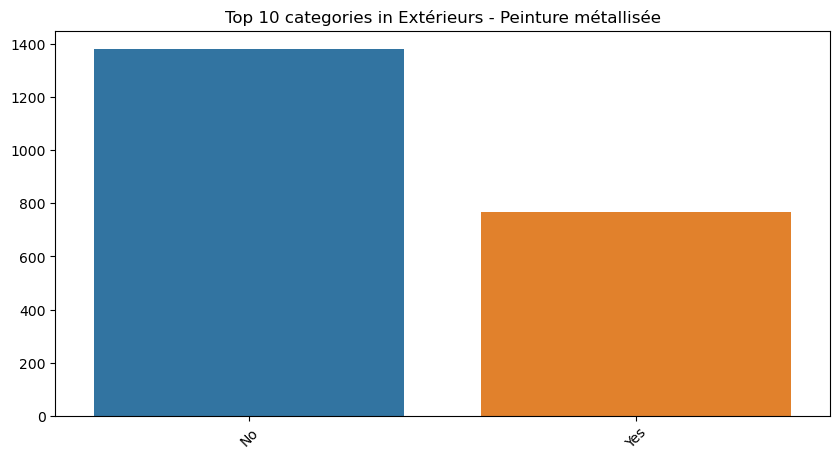

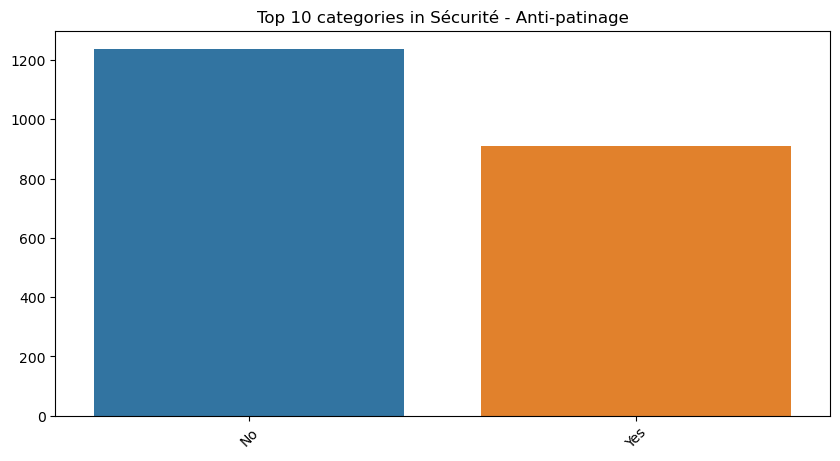

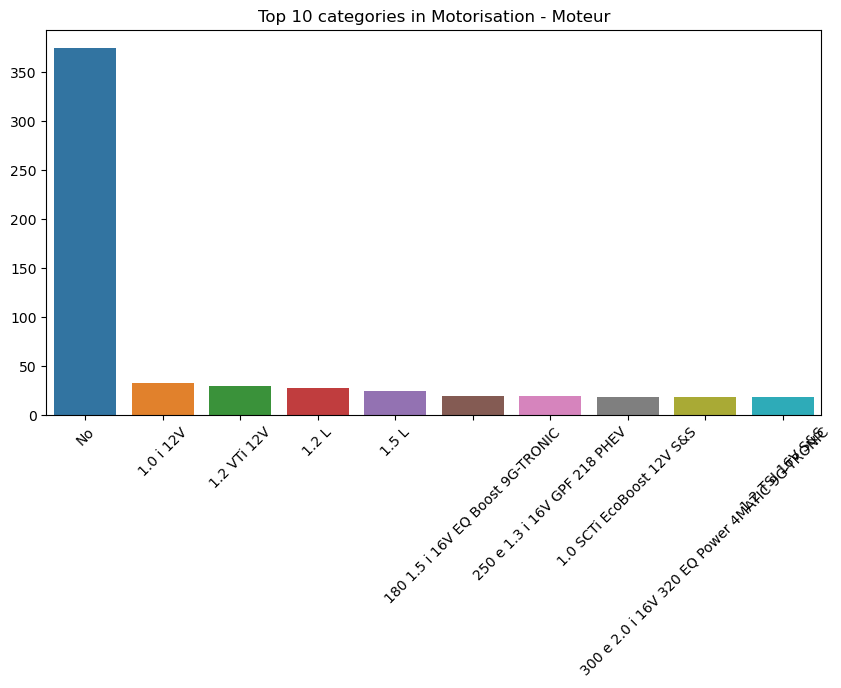

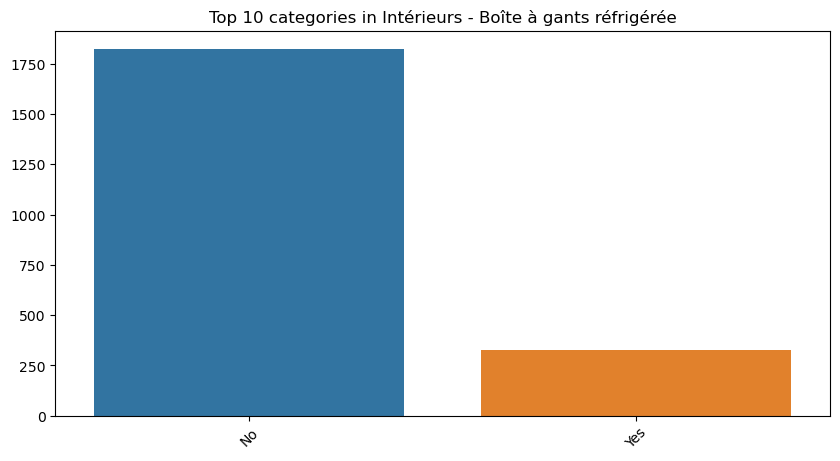

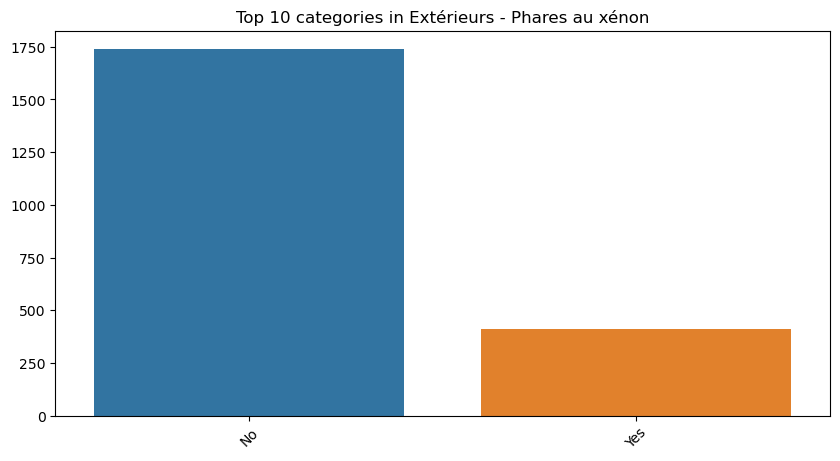

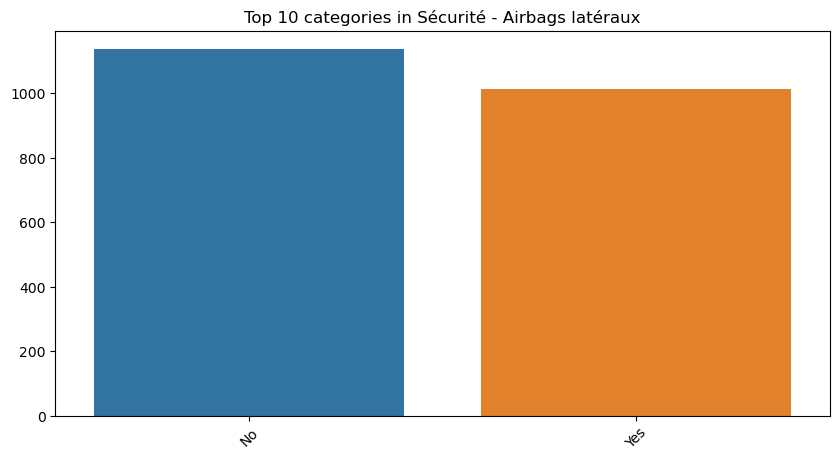

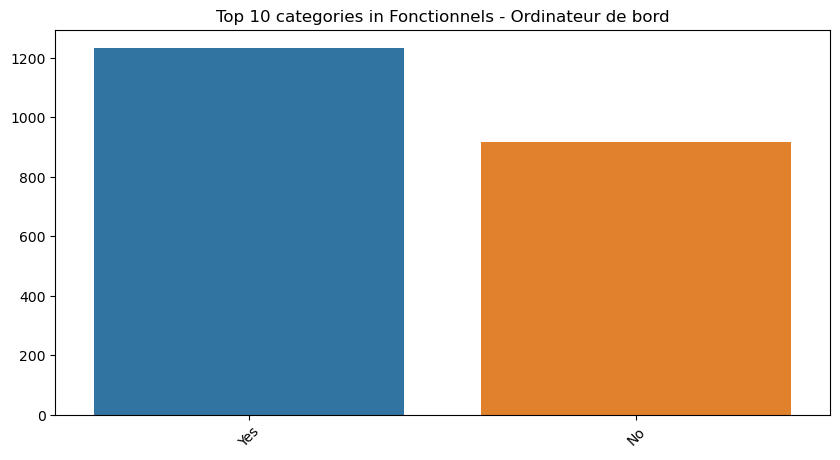

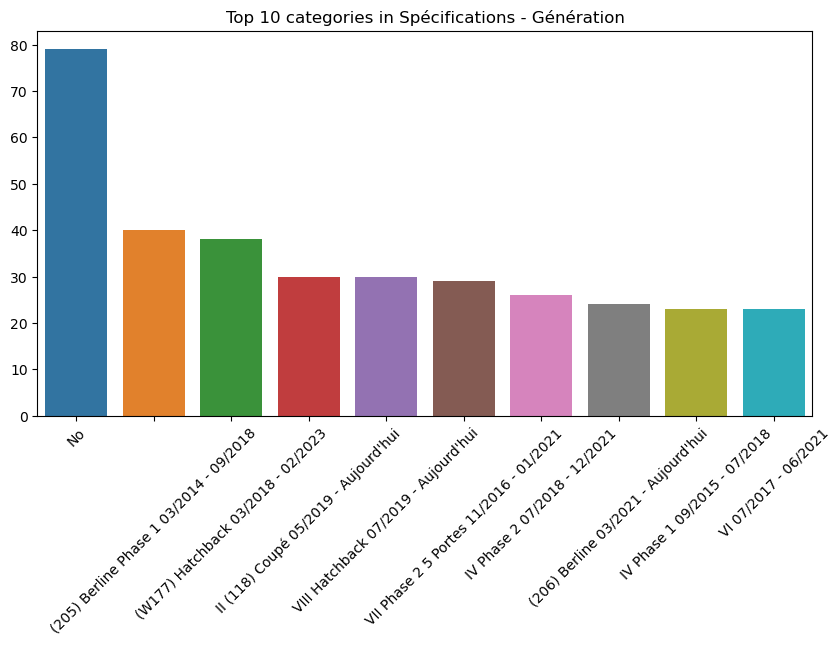

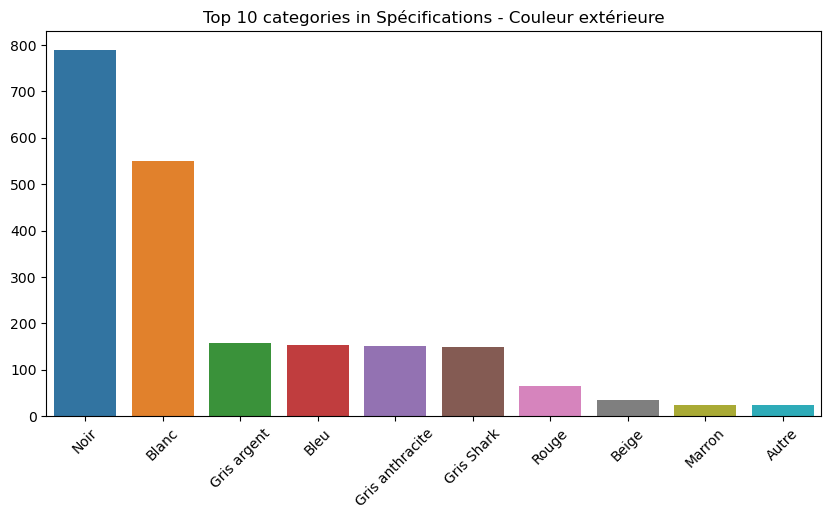

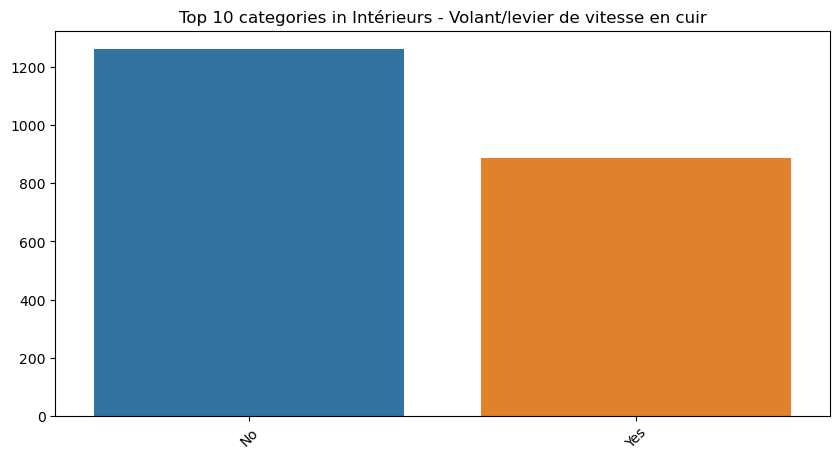

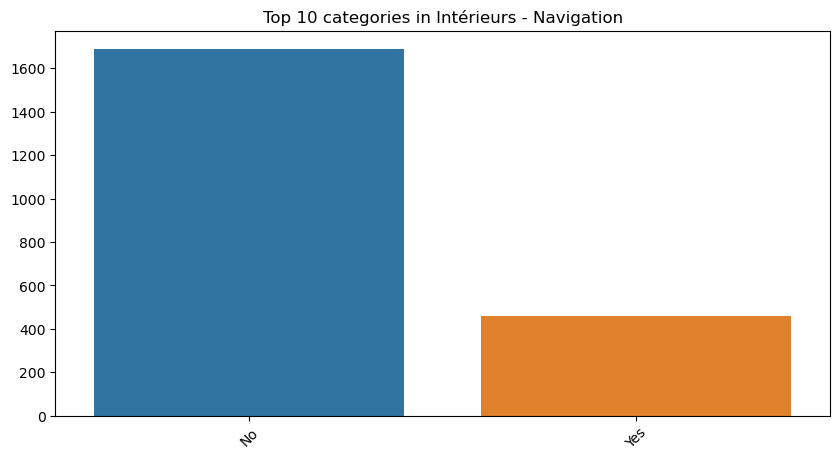

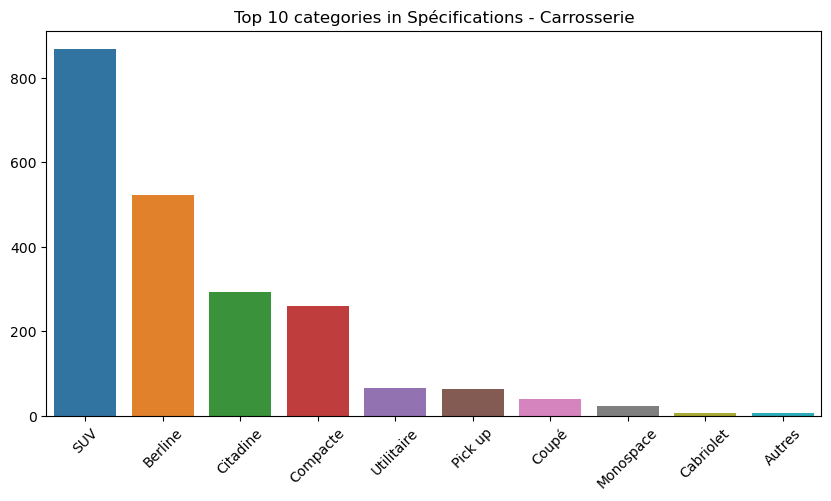

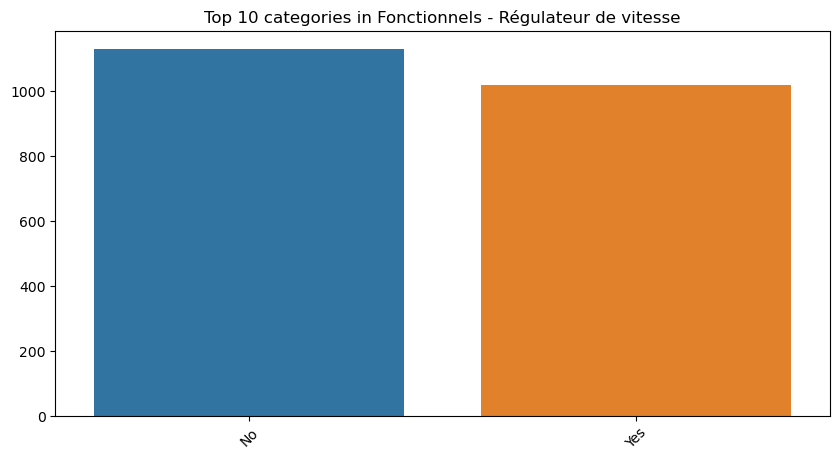

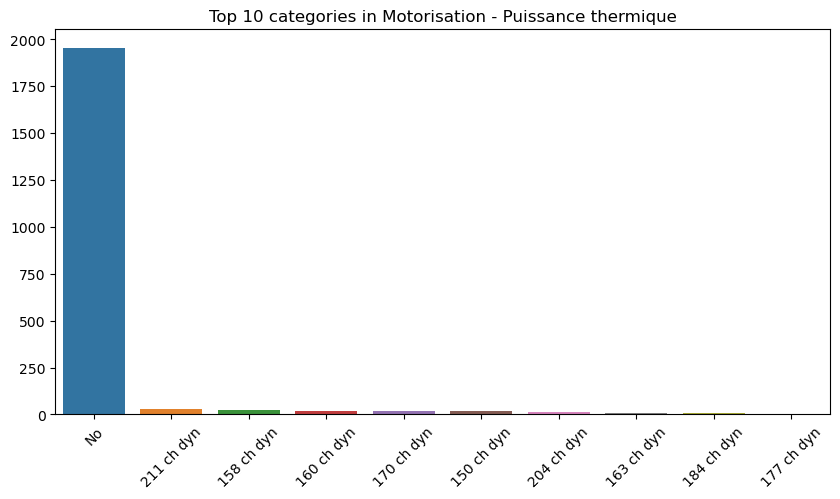

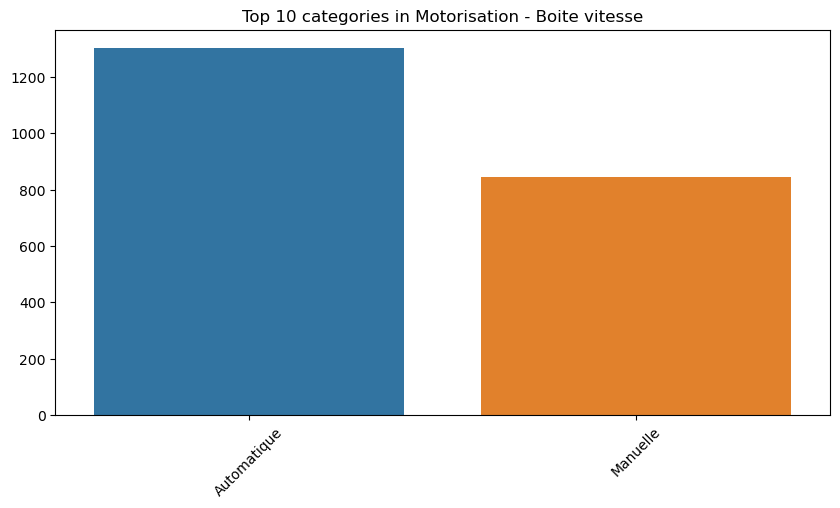

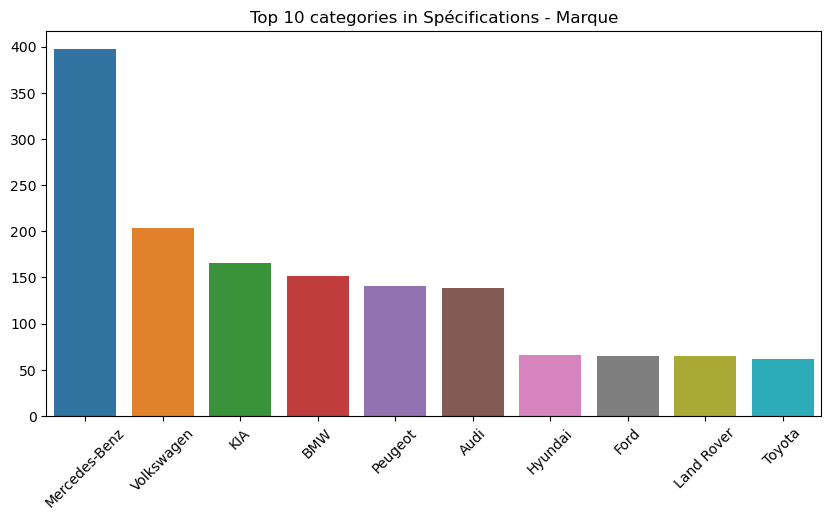

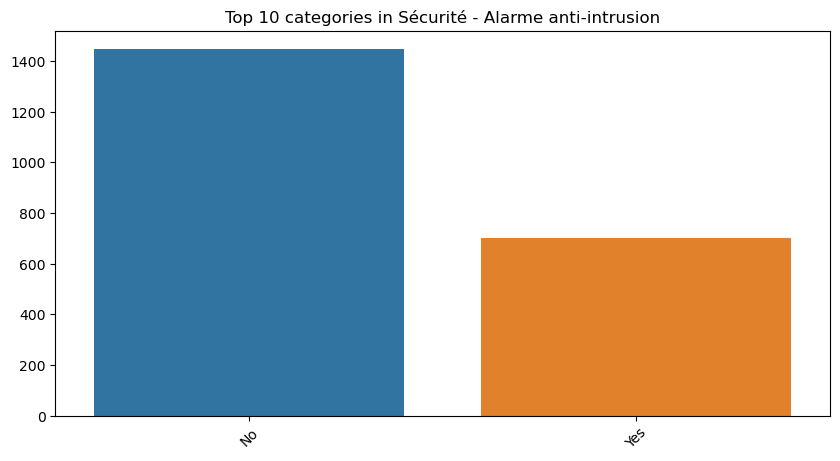

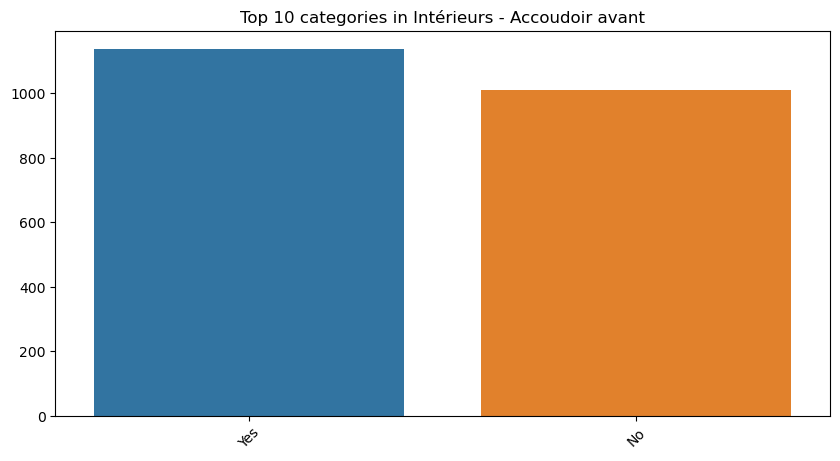

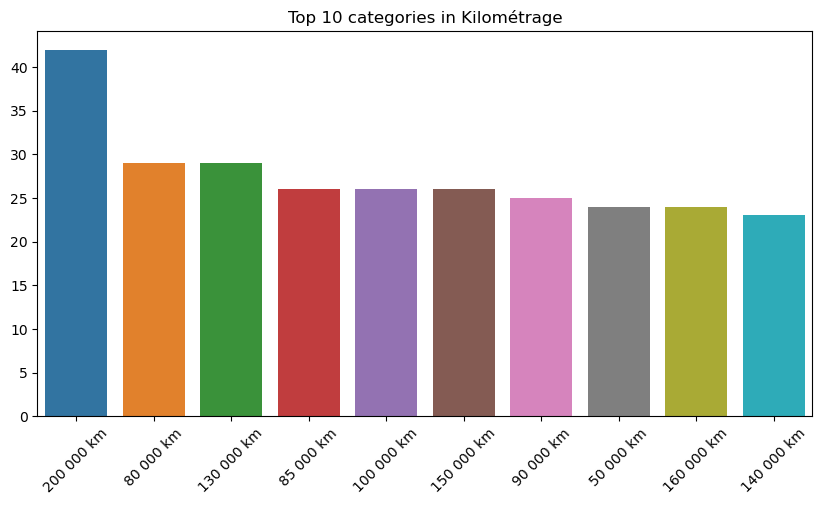

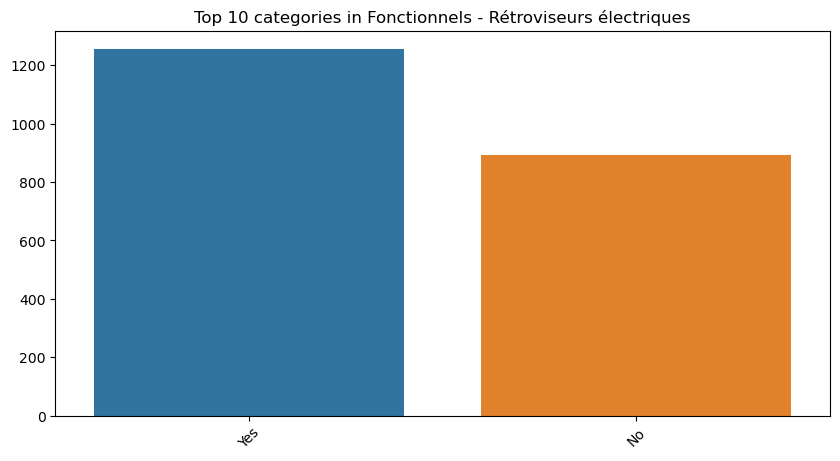

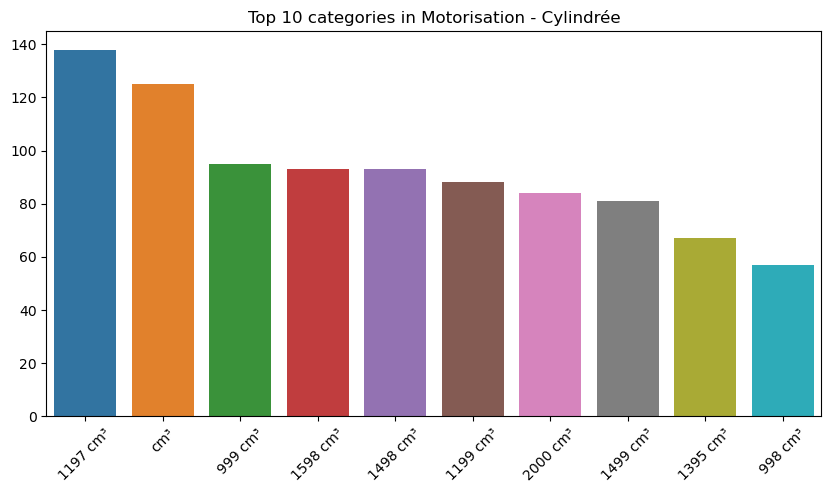

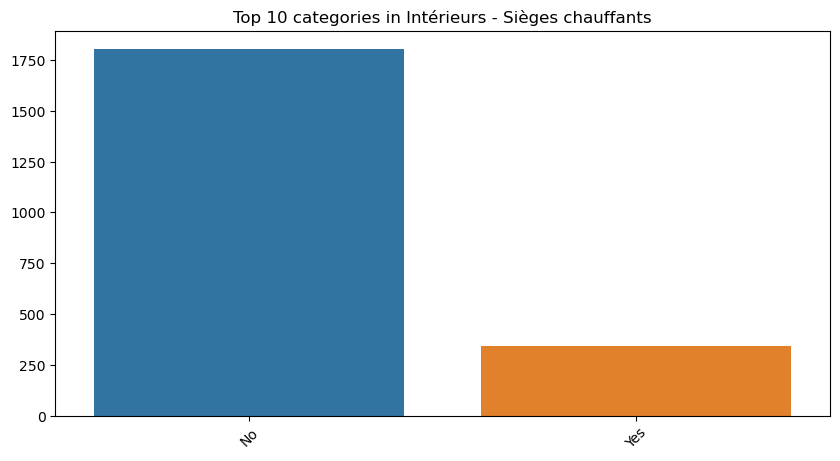

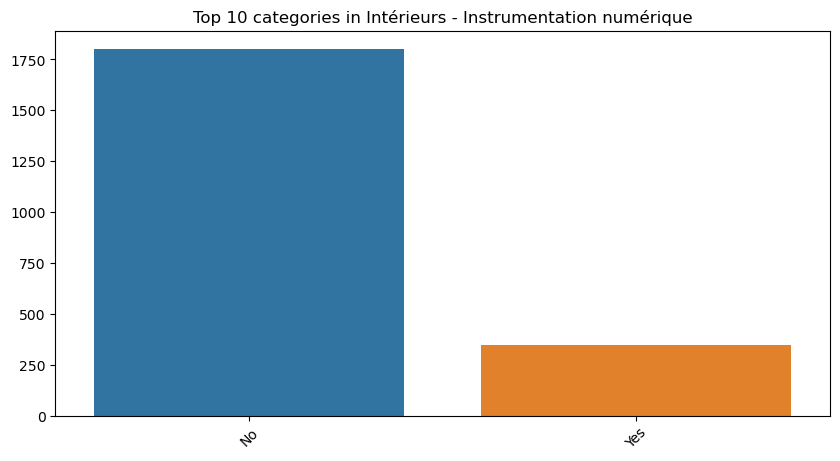

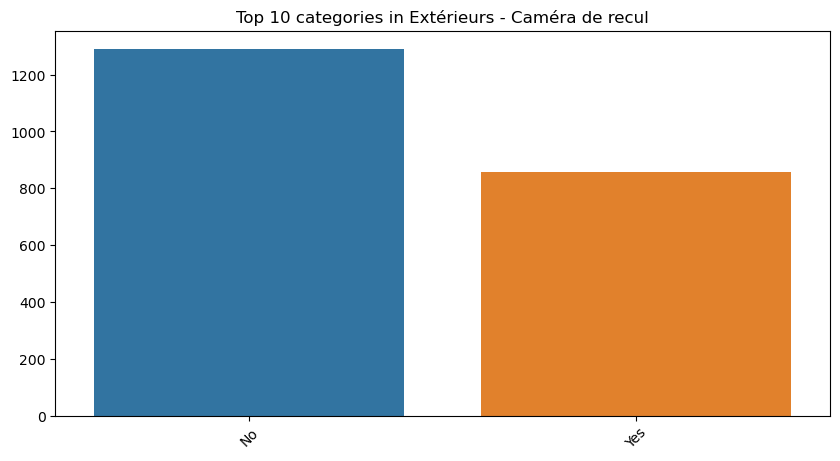

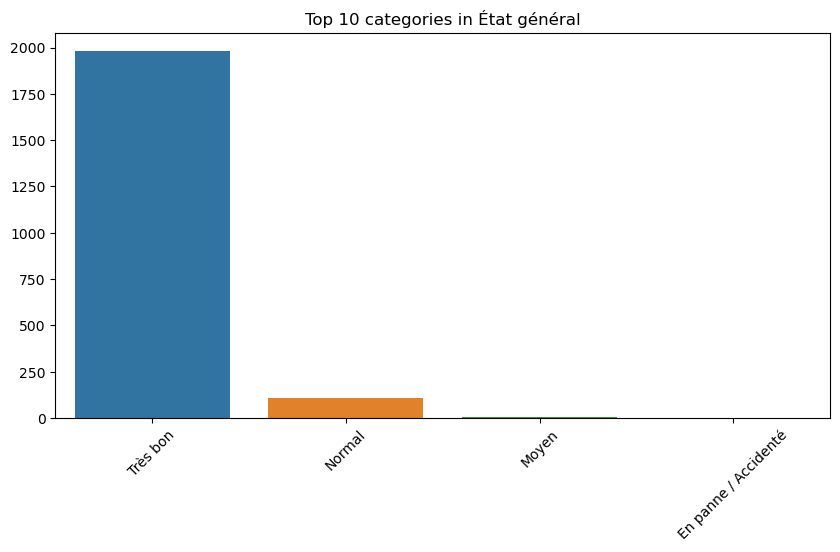

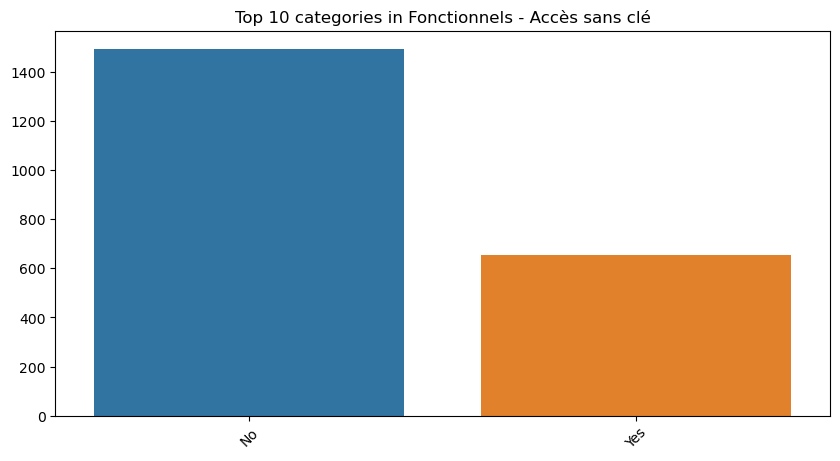

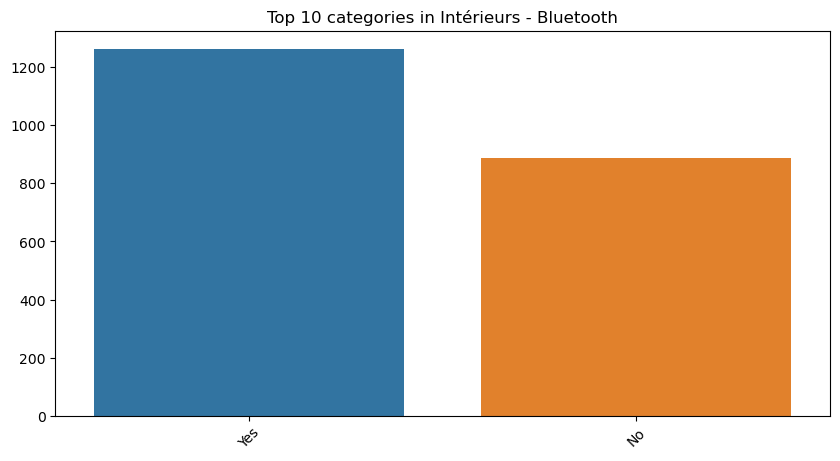

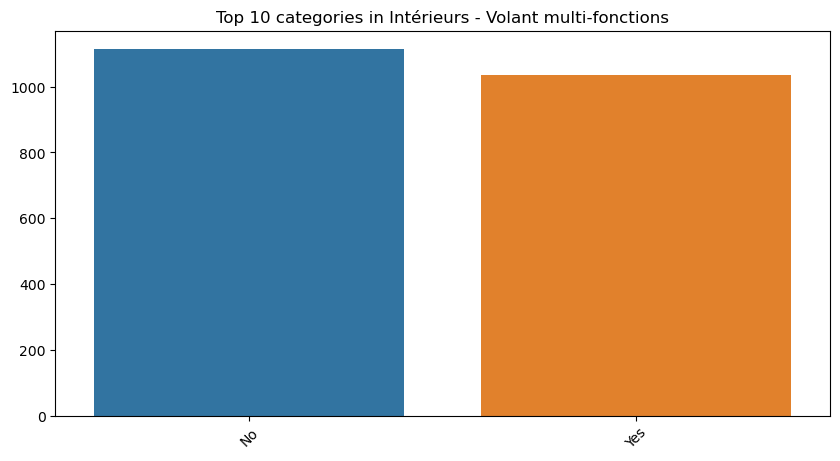

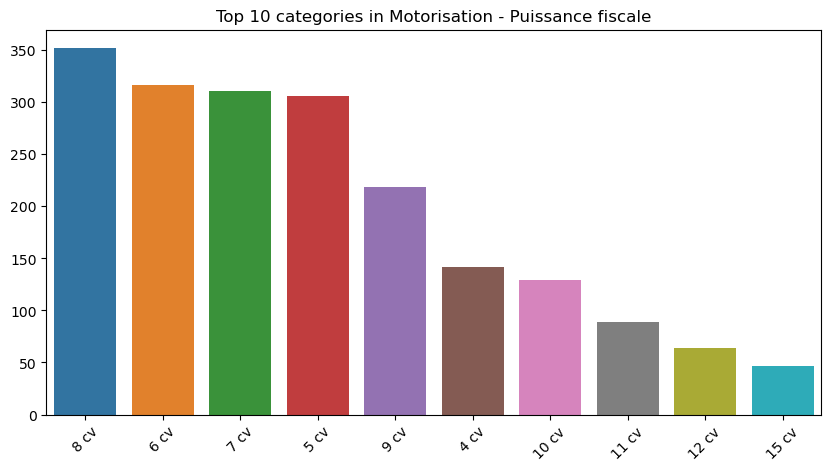

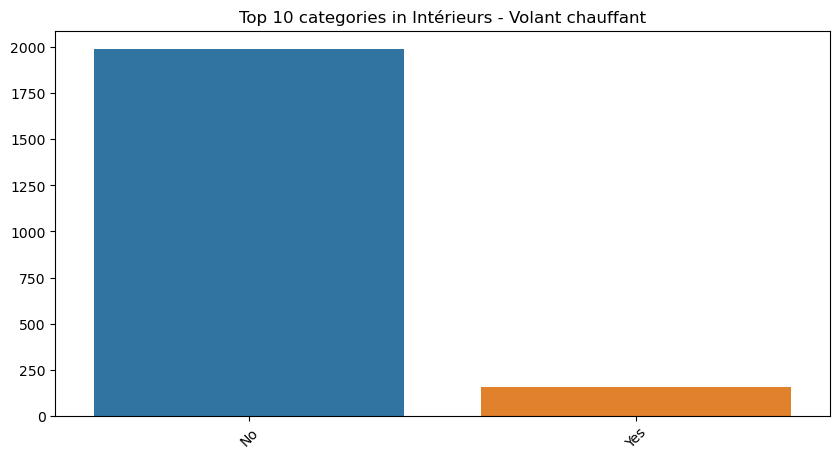

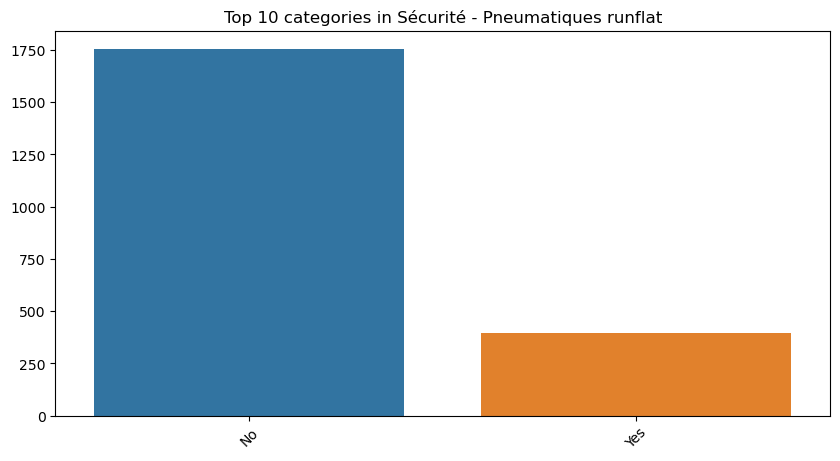

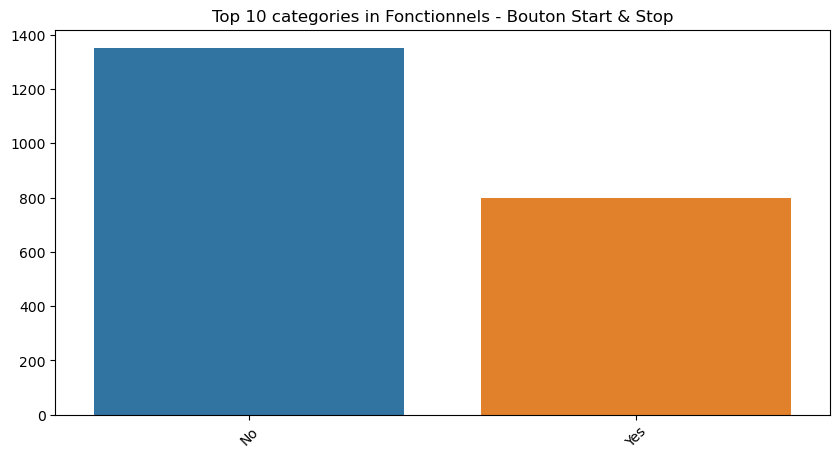

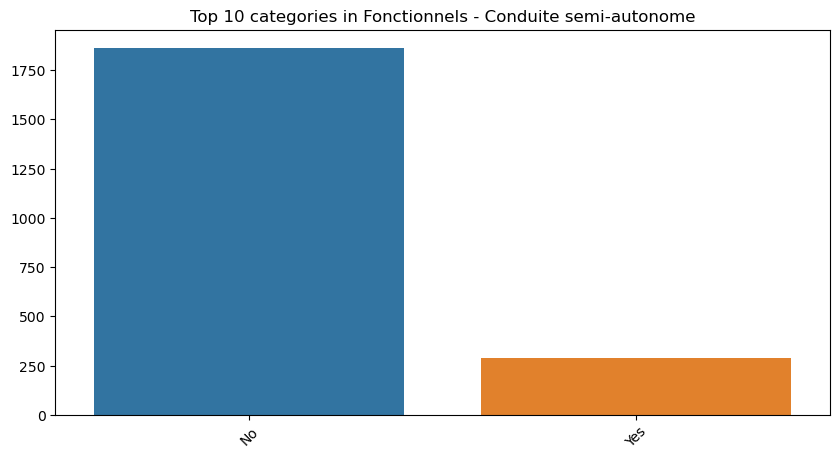

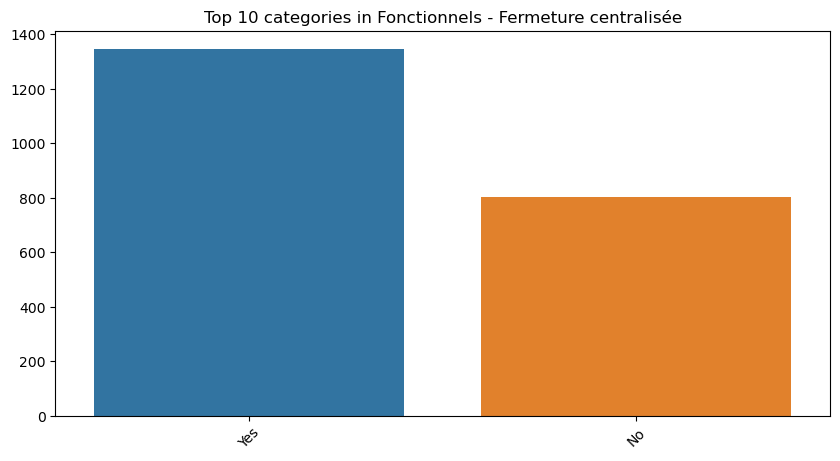

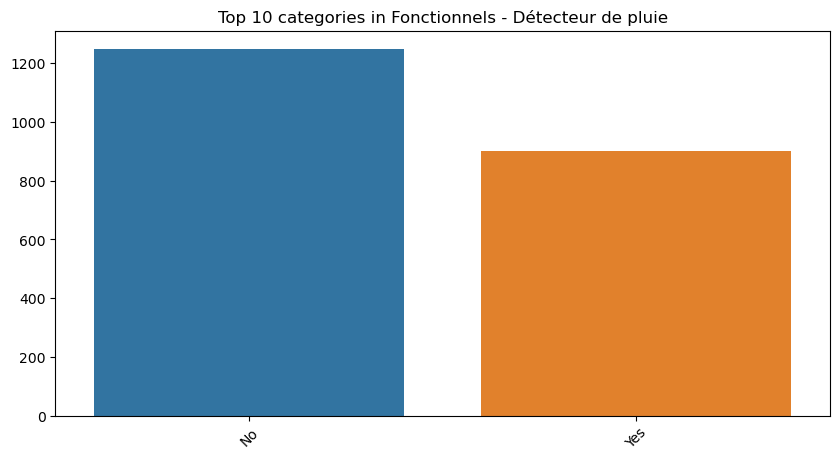

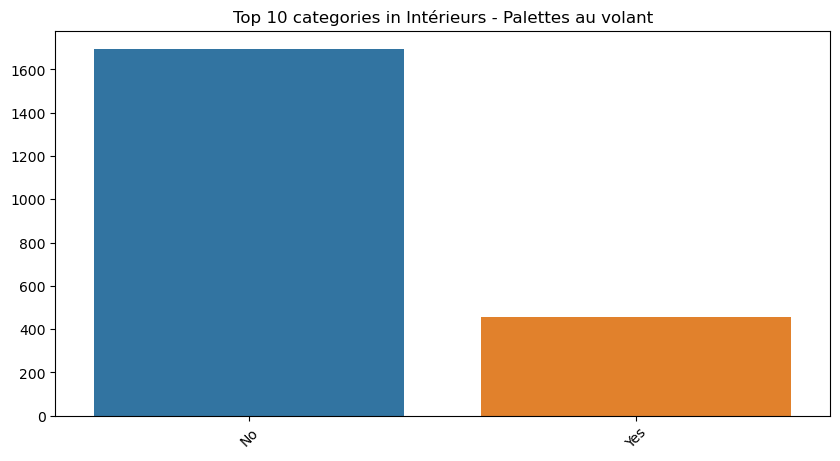

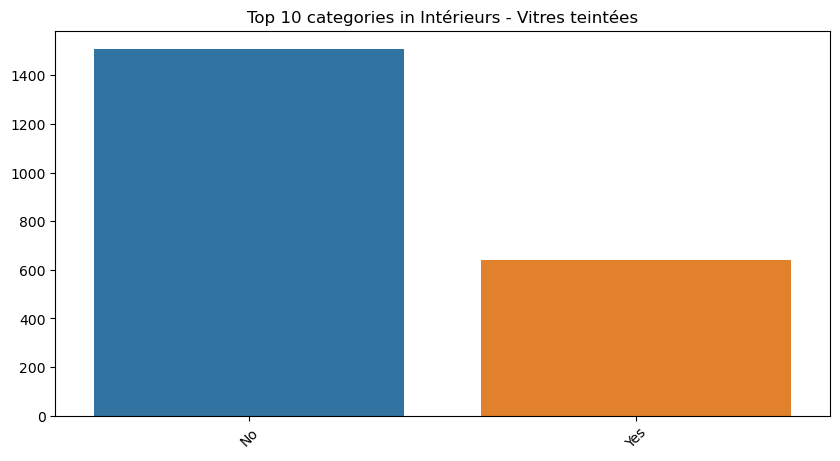

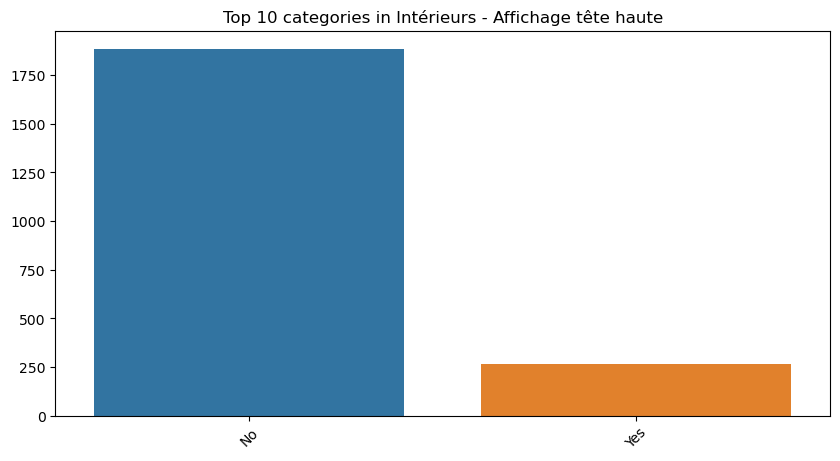

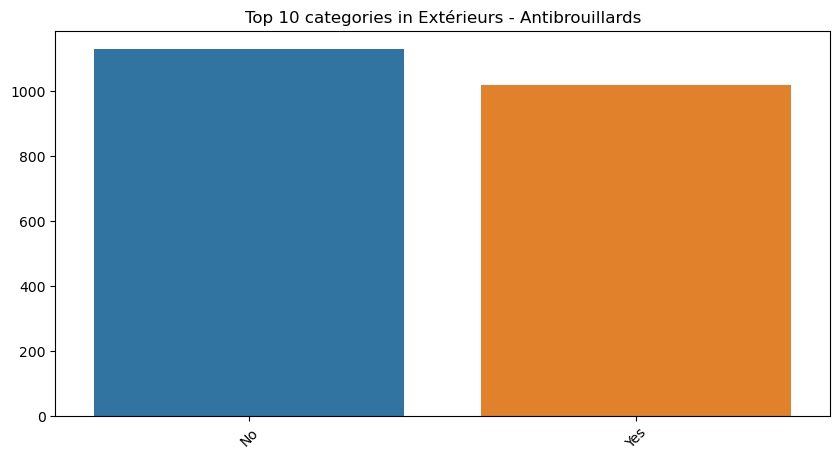

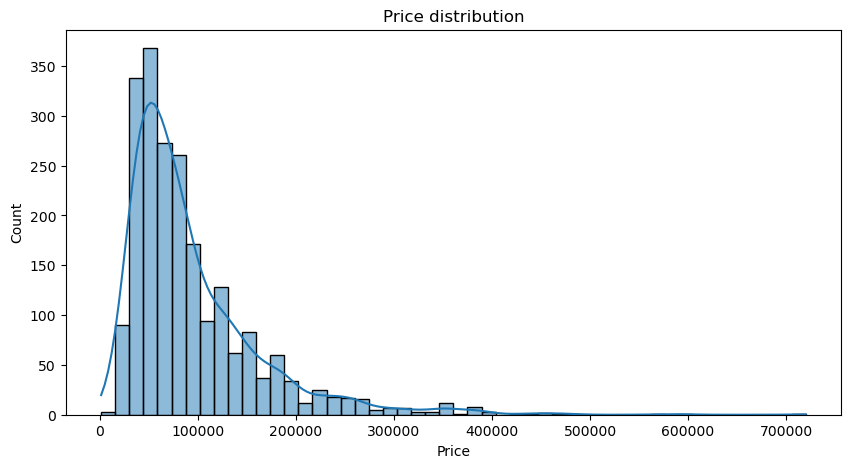

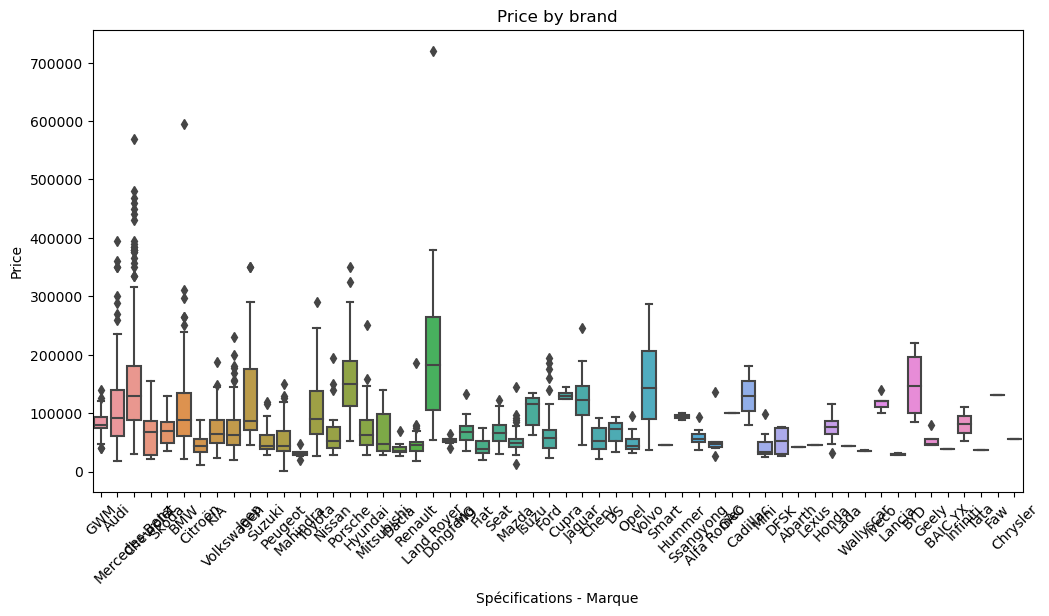

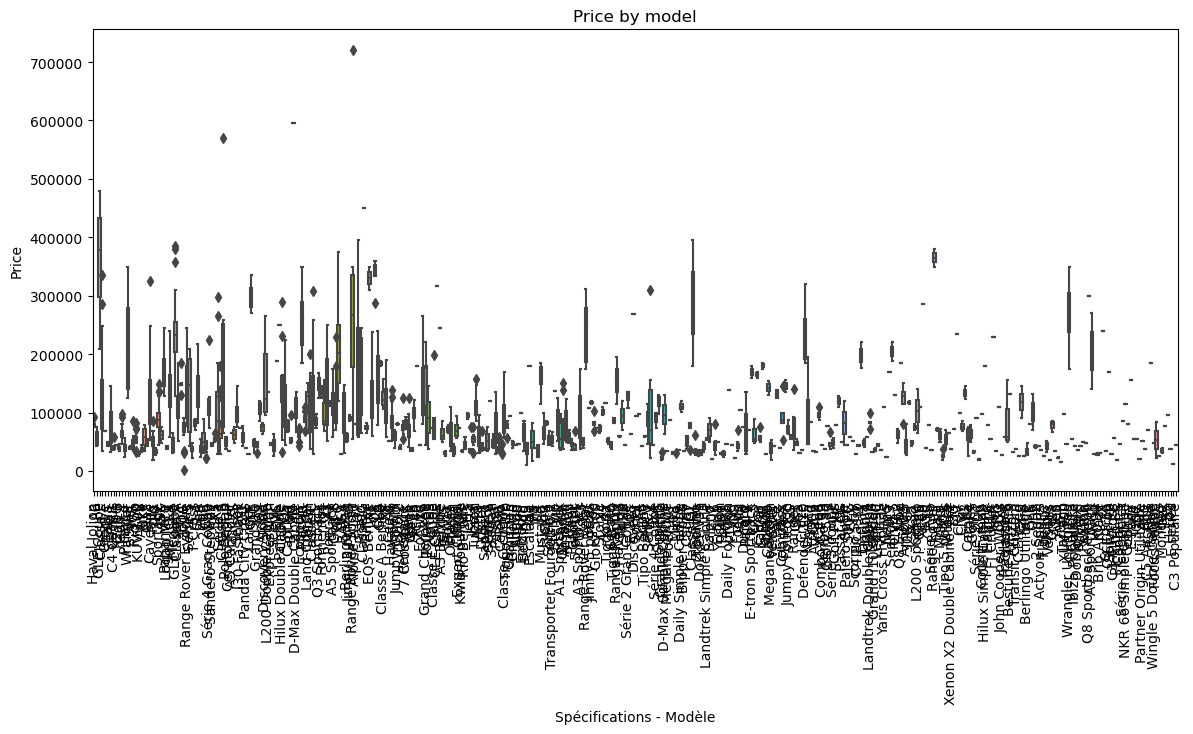

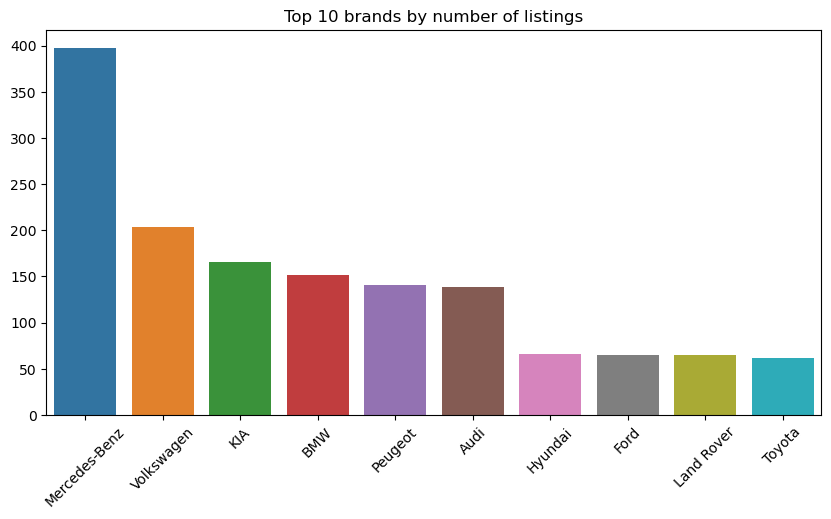

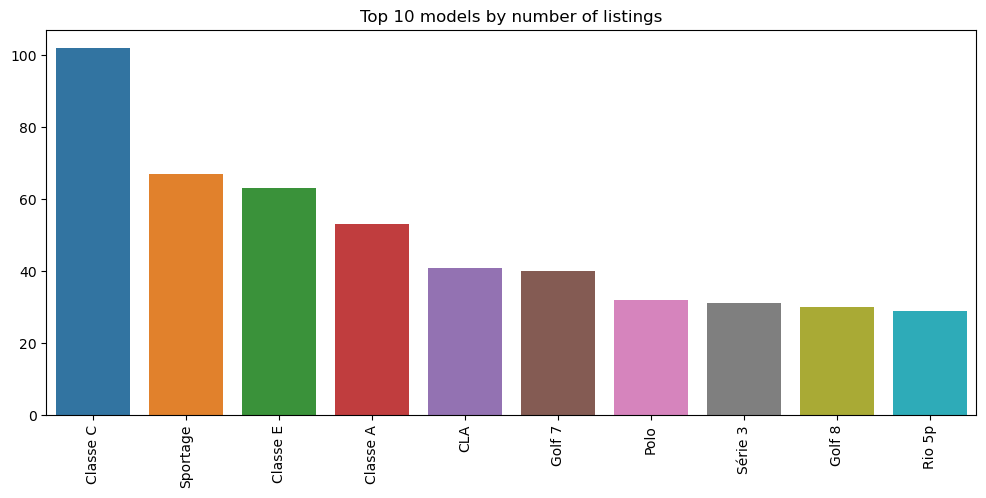

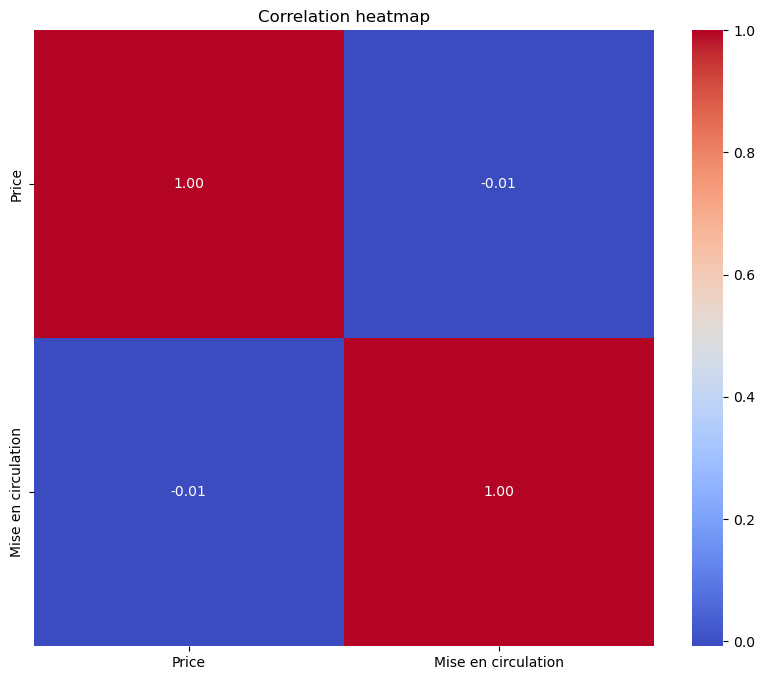


Brand stats:
                                   mean    median  count
Spécifications - Marque                                
Mercedes-Benz            148146.851385  129000.0    397
Volkswagen                71369.607843   63000.0    204
KIA                       70142.801205   65000.0    166
BMW                      108749.006623   88000.0    151
Peugeot                   51791.425532   44000.0    141
Audi                     111717.391304   92500.0    138
Hyundai                   71850.000000   62500.0     66
Ford                      65043.815385   58000.0     65
Land Rover               200876.923077  182000.0     65
Toyota                   103496.774194   89950.0     62
Renault                   46668.421053   45000.0     57
Citroën                   45990.740741   43500.0     54
Seat                      67815.384615   66500.0     52
GWM                       82981.632653   79000.0     49
MG                        66359.512195   67000.0     41
Nissan                    62560.5

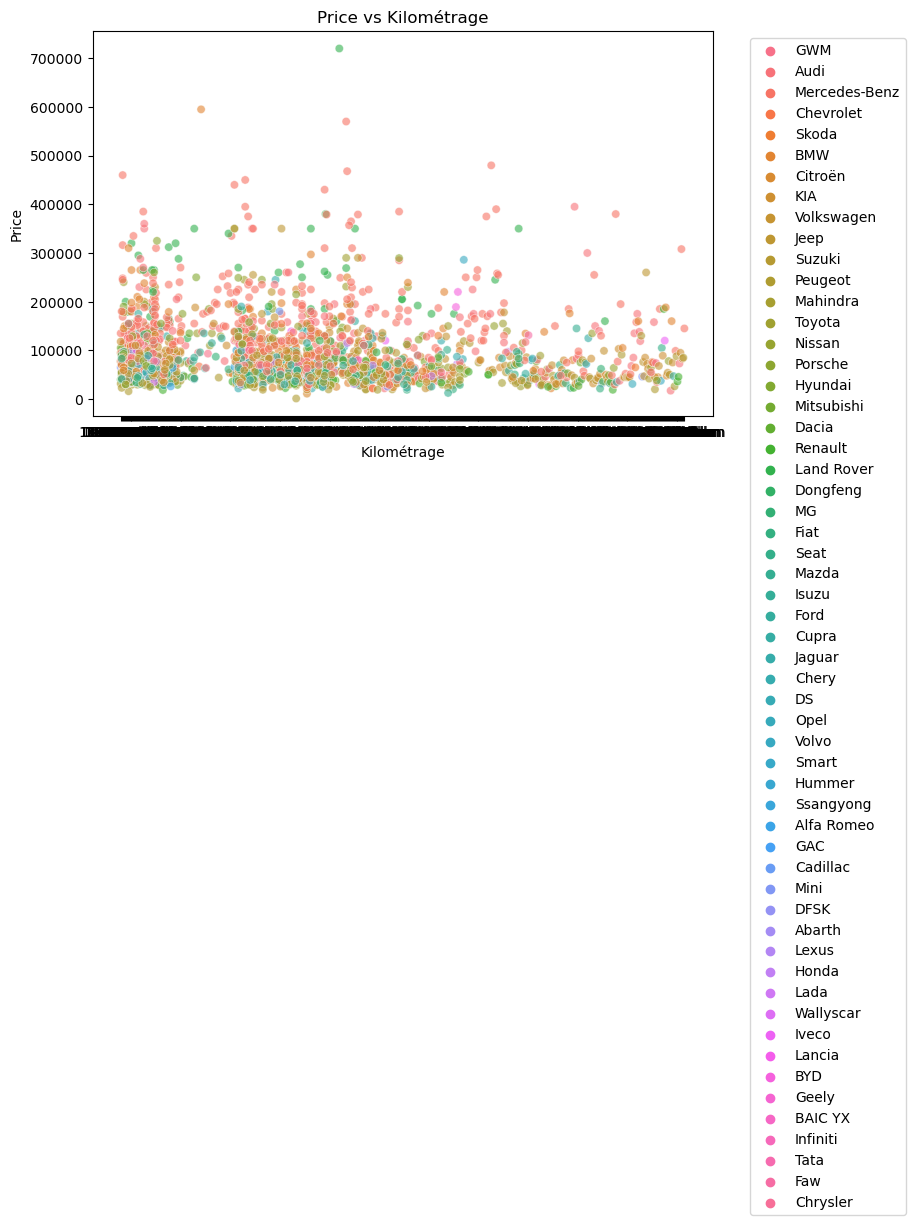

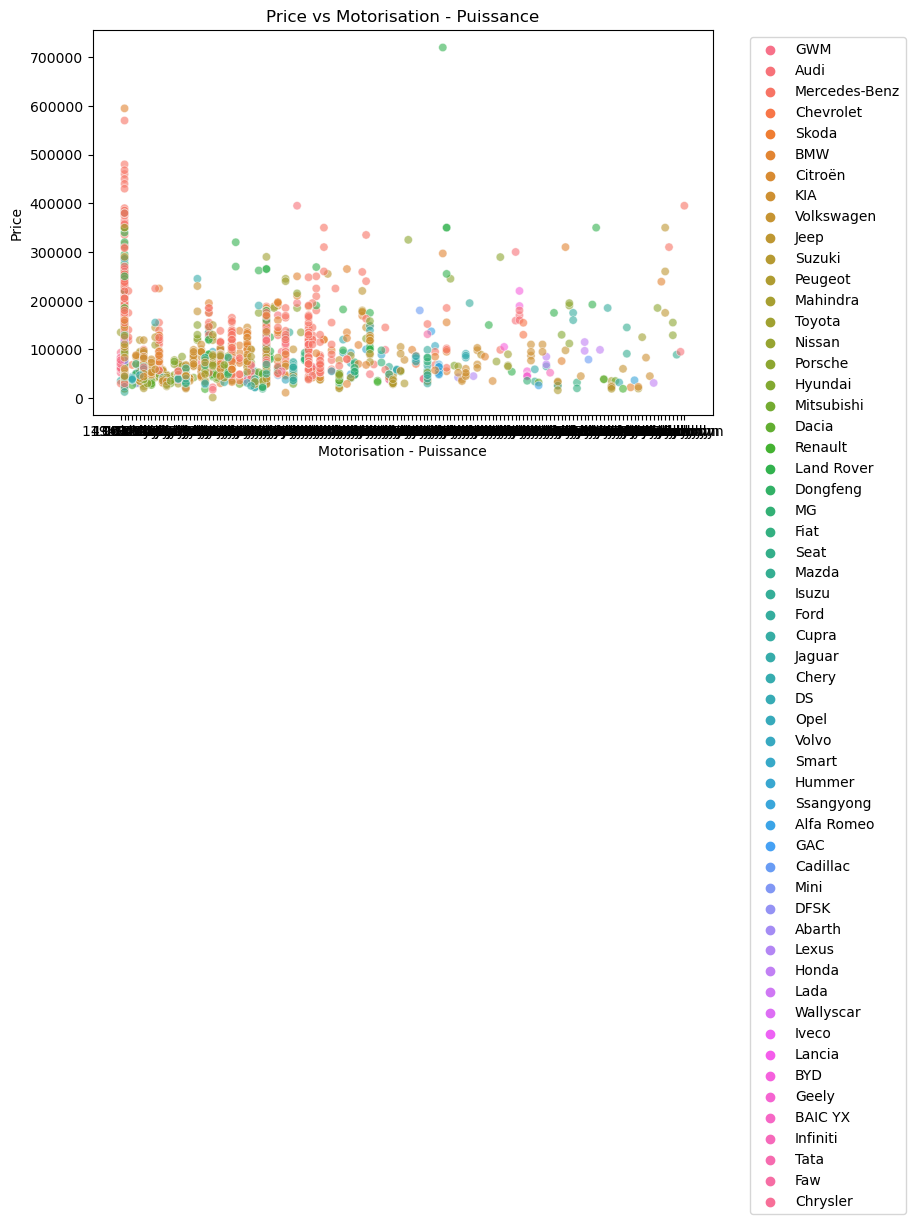

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv("../data_scraper/data_scraped/automobileTnUsed.csv")

# ---------- 1. Basic overview ----------
print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values:\n", df.isna().sum())
print("\nData types:\n", df.dtypes)

# ---------- 2. Numeric summary ----------
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("\nNumeric summary:\n", df[numeric_cols].describe())

# Histograms for all numeric columns
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col].dropna(), bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Boxplots for all numeric columns grouped by brand
for col in numeric_cols:
    plt.figure(figsize=(12,5))
    sns.boxplot(x='Spécifications - Marque', y=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} by Brand')
    plt.show()

# ---------- 3. Categorical summary ----------
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("\nCategorical summary:")
for col in cat_cols:
    print(f"\n{col} unique values: {df[col].nunique()}")
    print(df[col].value_counts().head(10))

# Barplots for top 10 categories in each categorical column
for col in cat_cols:
    top_vals = df[col].value_counts().head(10)
    plt.figure(figsize=(10,5))
    sns.barplot(x=top_vals.index, y=top_vals.values)
    plt.xticks(rotation=45)
    plt.title(f'Top 10 categories in {col}')
    plt.show()

# ---------- 4. Price analysis ----------
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Price distribution')
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='Spécifications - Marque', y='Price', data=df)
plt.xticks(rotation=45)
plt.title('Price by brand')
plt.show()

plt.figure(figsize=(14,6))
sns.boxplot(x='Spécifications - Modèle', y='Price', data=df)
plt.xticks(rotation=90)
plt.title('Price by model')
plt.show()

# ---------- 5. Top brands/models ----------
top_brands = df['Spécifications - Marque'].value_counts().head(10)
top_models = df['Spécifications - Modèle'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_brands.index, y=top_brands.values)
plt.xticks(rotation=45)
plt.title('Top 10 brands by number of listings')
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(x=top_models.index, y=top_models.values)
plt.xticks(rotation=90)
plt.title('Top 10 models by number of listings')
plt.show()

# ---------- 6. Correlations ----------
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation heatmap')
plt.show()

# ---------- 7. Grouped statistics ----------
brand_stats = df.groupby('Spécifications - Marque')['Price'].agg(['mean','median','count']).sort_values(by='count', ascending=False)
print("\nBrand stats:\n", brand_stats)

model_stats = df.groupby('Spécifications - Modèle')['Price'].agg(['mean','median','count']).sort_values(by='count', ascending=False)
print("\nModel stats:\n", model_stats.head(20))  # top 20 models

# ---------- 8. Optional: scatter plots for numeric pairs ----------
numeric_pairs = [('Kilométrage','Price'), ('Motorisation - Puissance','Price')]
for x_col, y_col in numeric_pairs:
    if x_col in df.columns and y_col in df.columns:
        plt.figure(figsize=(8,5))
        sns.scatterplot(x=x_col, y=y_col, hue='Spécifications - Marque', data=df, alpha=0.6)
        plt.title(f'{y_col} vs {x_col}')
        plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
        plt.show()
